In [ ]:
import sys
import os
import pickle
# Add project root to path (one level up from notebooks directory)
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Remove if already exists
if project_root in sys.path:
    sys.path.remove(project_root)

# Add at the beginning
sys.path.insert(0, project_root)

print("Project root:", project_root)
print("Python path after update:", sys.path[:3])

In [ ]:
import os
import inspect
import sys

# Get the actual file path of simulation_params.py
from src.config import simulation_params

print("simulation_params.py is loaded from:", inspect.getfile(simulation_params))
print("\nCurrent working directory:", os.getcwd())
print("\nPython path:", sys.path)

print("\nParameters from simulation_params.py vs current values:")
print("-" * 50)
param_vars = [var for var in dir(simulation_params) if var.isupper()]
for var in param_vars:
    sim_val = getattr(simulation_params, var)
    current_val = locals().get(var, "Not set yet")
    if sim_val != current_val and var in locals():
        print(f"{var}:")
        print(f"  simulation_params.py: {sim_val}")
        print(f"  current value: {current_val}")
        print()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.config import *
from src.utils import parse_evidence,extract_hist_data

from src.utils import plot_human_vs_simulated_data,plot_true_vs_recovered_params,plot_recovery_and_ll,plot_fitted_param_correlations,plot_param_correlations,plot_sim_vs_fit,plot_fitted_param_correlations_scatter
import pandas as pd
from src.params_fitting.data_simulation import simulate_data
# from src.params_fitting import generate_meg_data, get_horizon_keys
from src.utils import find_early_deciders_all_simulated

from src.utils import extract_draws_for_subject,extract_hist_data_for_user
from src.utils import get_subject_data,extract_hist_data,extract_draws_for_subject
from sklearn.metrics import r2_score
import re
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


In [ ]:
algorithm = ALGORITHM
max_cards_per_draw = MAX_CARDS_PER_DRAW
param_order = PARAM_ORDER
param_ranges = PARAM_RANGES
n_subjects = N_SUBJECTS
n_jobs = N_JOBS
figure_path = FIGURE_PATH
data_path = DATA_PATH
file_path = HUMAN_DATA_PATH
all_evidence_path = ALL_EVIDENCE_PATH
full_sim_df_path = FULL_SIM_DF_PATH
results_path = RESULTS_PATH
full_sim_df_recovered_path = FULL_SIM_DF_RECOVERED_PATH
results_recovered_path = RESULTS_RECOVERED_PATH
is_hazardous = IS_HAZARDOUS
is_latex=False

In [ ]:

print(f"Current Working Directory: {os.getcwd()}")

In [ ]:
metrics_save_path = os.path.join(data_path, "ensemble_metrics_summary.csv")
ensemble_save_path = os.path.join(data_path, "ensemble_distribution_data.pkl")

# upload the ocr.csv file 
ocir_file_path = os.path.join( "../data/TrHu_NHB_light/data_MEG/fa_scores.csv")
ybocs_path=os.path.join("../data/TrHu_NHB_light/data_MEG/ybocs_scores.csv")
ocir_data = pd.read_csv(ocir_file_path)
ybocs_data=pd.read_csv(ybocs_path)
# obtain the userID when the other row values are not non
ocd_userID=ybocs_data[ybocs_data.drop(columns='userID').notna().all(axis=1)]['userID']
non_ocd_userID=ybocs_data[ybocs_data.drop(columns=['userID']).isna().all(axis=1)]['userID']
# extract ocd_userID who has YBOCS_total_score column with value more than 12 and non nan
ocd_userID = ocd_userID[ybocs_data[ybocs_data['userID'].isin(ocd_userID)]['YBOCS_obsess_subtotal'] > 11].tolist()

In [ ]:
project_root

In [ ]:
# filter human data that are only in bad_subjects_IDs

In [ ]:
file_path = os.path.join("../data/TrHu_NHB_light/data_MEG/behdat_preprocessed.pkl")
human_data=pd.read_pickle(HUMAN_DATA_PATH)
# extract the subjects. 
# human_data_filtered=human_data[human_data["userID"].isin(bad_subjects_IDs)]
human_data_filtered=human_data[:n_subjects]
results_df=pd.read_pickle(results_path)

all_simulated_data = pd.read_pickle(full_sim_df_path)
results_df_recovered=pd.read_pickle(results_recovered_path)
simulated_subject_dfs_recovered = pd.read_pickle(full_sim_df_recovered_path)
# # 

In [ ]:
file_path = os.path.join("../data/TrHu_NHB_light/data_MEG/behdat_reward.pkl")
human_data=pd.read_pickle(HUMAN_DATA_PATH)


In [ ]:
short_draws_humans, long_draws_humans, short_rewards_humans, long_rewards_humans = extract_hist_data(human_data_filtered)
num_draws_human=short_draws_humans+long_draws_humans
outcome_human=long_rewards_humans+short_rewards_humans

In [ ]:
horizon= 'combined' if len(FIT_HORIZON)==2 else FIT_HORIZON[0]

In [ ]:

# plot the same figures but for the all_simulated_data
outcome_simulated = all_simulated_data['outcome'].values
ev_simulated = all_simulated_data['ev'].tolist()

# number of draws for simulated data
num_draws_simulated = []
for evidence in ev_simulated:
    # parsed = parse_evidence(evidence)
    num_draws_simulated.append(len(evidence))

num_draws_simulated = np.array(num_draws_simulated, dtype=int)
#

In [ ]:
if isinstance(FIT_HORIZON, list) and 'long' in FIT_HORIZON and 'short' in FIT_HORIZON:
    plot_human_vs_simulated_data(
        outcome_human, num_draws_human,outcome_simulated, num_draws_simulated,horizon='combined',path=figure_path
    )
elif isinstance(FIT_HORIZON, list) and 'short' in FIT_HORIZON:
    plot_human_vs_simulated_data(
        short_rewards_humans, short_draws_humans,
        outcome_simulated, num_draws_simulated,horizon='short',path=figure_path
    )
elif isinstance(FIT_HORIZON, list) and 'long' in FIT_HORIZON:
    plot_human_vs_simulated_data(
        long_rewards_humans, long_draws_humans,
        outcome_simulated, num_draws_simulated,horizon='long',path=figure_path
    )


In [ ]:
# between the simulated and the human data, I want to know the exact game where they differ in either number of draws or outcome:


In [ ]:
plot_true_vs_recovered_params(results_df, param_order,results_df_recovered,horizon=horizon,path=figure_path)

In [ ]:
results_df['fit_params_ga'].iloc[0]

In [ ]:
# Assuming you already have:
true_params_all = np.array(list(results_df['fit_params_ga']))
fit_params_ga   = np.array(results_df_recovered['fit_params_ga'].tolist())
after_lls_ga    = results_df_recovered['after_lls_ga'].tolist()

plot_recovery_and_ll(
    true_params_all, fit_params_ga, after_lls_ga,
    results_df, results_df_recovered,
    param_order, param_ranges,
    ocd_userID=ocd_userID,
    font_size=20,plot_regression=True,horizon=horizon,path=figure_path
)


In [ ]:
# for the lapse_hazard parameter I want to return the userIDs for subjects who recovered lapse_hazard parameter, so the true and recovered values are close to each   other
if isinstance(FIT_HORIZON, list) and 'long' in FIT_HORIZON:
    # 1. Define the tolerance for what counts as "close"
    # Adjust this threshold based on the expected scale of the lapse_hazard parameter
    tolerance = 0.01

    # 2. Find the index of 'lapse_hazard' in your param_order list
    lapse_idx = param_order.index('hazard_lapse')

    # 3. Extract the true and recovered arrays specifically for lapse_hazard
    true_lapse = true_params_all[:, lapse_idx]
    recovered_lapse = fit_params_ga[:, lapse_idx]

    # 4. Calculate the absolute difference and create a boolean mask
    # True where the difference is less than your defined tolerance
    close_mask = np.abs(true_lapse - recovered_lapse) < tolerance

    # 5. Apply the mask to extract the corresponding userIDs
    subject_ids = results_df_recovered["subject_ID"].to_numpy()
    good_recovery_userIDs = subject_ids[close_mask]

    # Optional: Print the results
    print(f"Tolerance set to: {tolerance}")
    print(f"Number of subjects with successfully recovered lapse_hazard: {len(good_recovery_userIDs)}")
    print("User IDs:", good_recovery_userIDs)

In [ ]:
plot_param_correlations(true_params_all, fit_params_ga, param_order, method_name='GA',horizon=horizon,path=figure_path)


In [ ]:
fit_params_dict = {
    'GA': fit_params_ga,
    # Add other methods similarly if needed
}
plot_fitted_param_correlations(fit_params_dict, param_order, font_size=20, is_latex=False,horizon=horizon,path=figure_path)


In [ ]:

plot_fitted_param_correlations_scatter(fit_params_dict, param_order, font_size=20, is_latex=False,horizon=horizon,path=figure_path)

In [ ]:
# plot the same figures but for the all_simulated_data
outcome_simulated_fit = simulated_subject_dfs_recovered['outcome'].values
ev_simulated_fit = simulated_subject_dfs_recovered['ev'].tolist()
# number of draws for simulated data, loop over the ev and calculate the length of each evidence, then add a new column to simulated data frame and assign for each row the corresponding number of draws
num_draws_simulated_fit = []
for evidence in ev_simulated_fit:
    # the evidence is a list from csv, that was converted from .mat, I think the len(evidence) counts the number of spaces as it's not seperated by commas
    # so I need to convert it to a list of integers
    num_draws_simulated_fit.append(len(evidence))
    if len(evidence) > 25:
        print("Number of draws is greater than 25")
        print(evidence)
        print(len(evidence))
        break
num_draws_simulated_fit = np.array(num_draws_simulated_fit)

In [ ]:
plot_sim_vs_fit( outcome_simulated_fit, num_draws_simulated_fit,
                 outcome_simulated, num_draws_simulated,path=figure_path)


In [ ]:


# prefer the actual column names in this all_simulated_data
preferred_subject_col = 'subject_id' if 'subject_id' in all_simulated_data.columns else None
preferred_ev_col = 'ev' if 'ev' in all_simulated_data.columns else None
preferred_draw_col = 'action' if 'action' in all_simulated_data.columns else None

if preferred_subject_col is None:
    # fallback: use the stricter regex to guess a subject column
    _subject_re = re.compile(r'(^|[_\-\.\s])(?:subject|user(?:[_\-]?id)?|userid|user_id|subj|id)(?:$|[_\-\.\s])', re.I)
    candidates = [c for c in all_simulated_data.columns if _subject_re.search(c)]
    preferred_subject_col = candidates[0] if candidates else None

if preferred_subject_col is None:
    # final fallback: add index as subject id
    df_for_search = all_simulated_data.reset_index().rename(columns={all_simulated_data.index.name or 'index': 'subject_ID'})
    print("No subject id column found — using index as 'subject_ID' (added column).")
else:
    df_for_search = all_simulated_data

# find subjects who decided on the first draw (decision_draw == 1)
early_sim_df_first = find_early_deciders_all_simulated(
    df_for_search,
    subject_id_col_candidates=(preferred_subject_col if preferred_subject_col is not None else 'subject_ID',),
    ev_col_candidates=(preferred_ev_col,) if preferred_ev_col is not None else ('ev', 'evidence', 'draws'),
    draw_col_candidates=(preferred_draw_col,) if preferred_draw_col is not None else ('action', 'draw_action', 'draw_yellow_blue_action'),
    max_draw=1,
    min_games=1,
    max_examples_per_subject=10
)

# explode so each example is a row and extract fields
exploded_first = early_sim_df_first[['subject_ID', 'early_details']].explode('early_details').reset_index(drop=True)
exploded_first = exploded_first[exploded_first['early_details'].notna()].copy()

exploded_first['decision_draw'] = exploded_first['early_details'].apply(lambda d: d.get('decision_draw') if isinstance(d, dict) else None)
exploded_first['yellow_sequence'] = exploded_first['early_details'].apply(lambda d: d.get('yellow_sequence') if isinstance(d, dict) else None)
exploded_first['yellow_sequence_predecision'] = exploded_first['early_details'].apply(lambda d: d.get('yellow_sequence_predecision') if isinstance(d, dict) else None)
exploded_first['example_seq'] = exploded_first['early_details'].apply(lambda d: d.get('example_seq') if isinstance(d, dict) else None)

# filter strictly for decision_draw == 1 (should hold given max_draw=1 but keep for safety)
first_draw = exploded_first[exploded_first['decision_draw'] == 1].copy()

# per-subject summary
summary_first_draw = first_draw.groupby('subject_ID').agg(
    n_first_draw=('decision_draw', 'count'),
    examples=('early_details', lambda s: list(s))
).reset_index().sort_values('n_first_draw', ascending=False)

print(f"Subjects with any decision at draw 1 (all_simulated_data): {summary_first_draw.shape[0]}")
print(summary_first_draw.head(50))

first_draw_records = first_draw[['subject_ID', 'decision_draw', 'yellow_sequence_predecision', 'yellow_sequence', 'example_seq']].reset_index(drop=True)
print(first_draw_records.head(50).to_dict(orient='records'))

# optional: save for inspection
# os.makedirs(os.path.join(project_root, 'outputs'), exist_ok=True)
# first_draw_records.to_csv(os.path.join(project_root, 'outputs', 'first_draw_decisions_all_simulated.csv'), index=False)
#

In [ ]:
# --- extract draws from all_simulated_data and from results_df ---
target_id=1
sim_draws = extract_draws_for_subject(all_simulated_data, target_id)
# get the parameters from results_df for 28 subject_ID
params=results_df[results_df['subject_ID'] == target_id]['fit_params_ga'].values
short_horizon_draws, long_horizon_draws, short_horizon_rewards, long_horizon_rewards = extract_hist_data_for_user(human_data, target_id)
sim_draws = extract_draws_for_subject(all_simulated_data, target_id)
outcome_simulated = all_simulated_data['outcome'].values
userId_list=human_data['userID'].unique().tolist()

In [ ]:

userId_list=human_data['userID'].unique().tolist()
target_id = userId_list[1]
sim_draws = extract_draws_for_subject(all_simulated_data, target_id)
outcome_target_id_simulated=all_simulated_data[all_simulated_data['userID']==target_id]['outcome'].values
bins=np.arange(1,14,1)
short_horizon_draws, long_horizon_draws, short_horizon_rewards, long_horizon_rewards = extract_hist_data_for_user(human_data, target_id)
# Compute histogram counts for each dataset
sim_counts, _ = np.histogram(sim_draws, bins=bins)
human_counts, _ = np.histogram(short_horizon_draws, bins=bins)
sim_outcome_counts,_=np.histogram(outcome_target_id_simulated,bins=bins)
human_outcome_counts,_=np.histogram(short_horizon_rewards,bins=bins)



total_absolute_error = np.sum(np.abs(sim_counts - human_counts))
mean_absolute_error = np.mean(np.abs(sim_counts - human_counts))
rmse = np.sqrt(np.mean((sim_counts - human_counts)**2))
# Calculate R² between the two histograms
r2_num_draws = r2_score(human_counts, sim_counts)

print(f'R2 for the number of draws: {r2_num_draws}')
print(f"Total Absolute Error: {total_absolute_error}")
print(f"Mean Absolute Error: {mean_absolute_error}")
print(f"Root Mean Square Error: {rmse}")

# same calculattions for outcome counts
total_absolute_error_outcome = np.sum(np.abs(sim_outcome_counts - human_outcome_counts))
mean_absolute_error_outcome = np.mean(np.abs(sim_outcome_counts - human_outcome_counts))
rmse_outcome = np.sqrt(np.mean((sim_outcome_counts - human_outcome_counts)**2))
# Calculate R² between the two histograms
r2_outcome = r2_score(human_outcome_counts, sim_outcome_counts)
print(f'R2 for the outcome: {r2_outcome}')
print(f"Total Absolute Error (outcome): {total_absolute_error_outcome}")    
print(f"Mean Absolute Error (outcome): {mean_absolute_error_outcome}")
print(f"Root Mean Square Error (outcome): {rmse_outcome}")


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from joblib import Parallel, delayed
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib

# ==========================================
# 1. Metric Computation Function
# ==========================================
def compute_subject_metrics(run_idx, userId_list, results_df, human_data, bins, FIT_HORIZON, raw_sim_dir):
    """Compute metrics and extract binned data for all subjects in one simulation run."""
    # Assuming simulate_data, extract_draws_for_subject, and extract_hist_data_for_user 
    # are defined elsewhere in your script.
    all_simulated_data, _ = simulate_data(results_df, sim_same_data=True)
    
    # --- ADDED: Save the raw trial-by-trial data for the GLM script ---
    # We save this as a pickle file which cleanly handles lists inside dataframes
    horizon_str = FIT_HORIZON[0]
    sim_file_path = os.path.join(raw_sim_dir, f"sim_run_{run_idx}_{horizon_str}.pkl")
    all_simulated_data.to_pickle(sim_file_path)
    # ------------------------------------------------------------------

    records = []
    
    # Specific bins to cleanly capture the discrete outcomes: -2, -1, 0, 1, 2
    # The '1' bin will naturally be empty if your data only has -2, -1, 0, 2
    outcome_bins = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
    
    for target_id in userId_list:
        sim_draws = extract_draws_for_subject(all_simulated_data, target_id)
        outcome_sim = all_simulated_data[all_simulated_data['userID'] == target_id]['outcome'].values
        
        # Extract human data based on FIT_HORIZON
        short_draws, long_draws, short_rewards, long_rewards = extract_hist_data_for_user(human_data, target_id)
        if FIT_HORIZON == ['short']:
            human_draws = short_draws
            human_outcome = short_rewards
        elif FIT_HORIZON == ['long']:
            human_draws = long_draws
            human_outcome = long_rewards
        else:  # both
            human_draws = short_draws + long_draws
            human_outcome = short_rewards + long_rewards
        
        # Compute histograms for draws
        sim_counts, _ = np.histogram(sim_draws, bins=bins)
        human_counts, _ = np.histogram(human_draws, bins=bins)
        
        # Compute histograms for outcomes using discrete bins
        sim_outcome_counts, _ = np.histogram(outcome_sim, bins=outcome_bins)
        human_outcome_counts, _ = np.histogram(human_outcome, bins=outcome_bins)
        
        r2_draws = r2_score(human_counts, sim_counts)
        r2_outcome = r2_score(human_outcome_counts, sim_outcome_counts)
        
        records.append({
            "userID": target_id,
            "r2_draws": r2_draws,
            "r2_outcome": r2_outcome,
            "sim_counts": sim_counts,        
            "human_counts": human_counts,
            "sim_outcome_counts": sim_outcome_counts,     
            "human_outcome_counts": human_outcome_counts  
        })
    
    return records

# check first if the simulations ran and the file exists to avoid rerunning the simulations
if os.path.exists(metrics_save_path) and os.path.exists(ensemble_save_path):
    print("Metrics and ensemble data already exist. Loading from disk...")
    metrics_df = pd.read_csv(metrics_save_path)
    with open(ensemble_save_path, 'rb') as f:
        ensemble_data = pickle.load(f)

else:
    # --- ADDED: Create the directory to hold the raw simulations ---
    # This assumes 'data_path' is defined earlier in your file where you define metrics_save_path
    raw_sim_dir = os.path.join(data_path, "raw_simulations")
    os.makedirs(raw_sim_dir, exist_ok=True)

    # ==========================================
    # 2. Parallel Execution
    # ==========================================
    num_runs = 300

    with tqdm_joblib(tqdm(desc="Runs", total=num_runs)) as progress_bar:
        total_records = Parallel(n_jobs=-1, verbose=1)(
            # --- EDITED: Pass raw_sim_dir to the function ---
            delayed(compute_subject_metrics)(i, userId_list, results_df, human_data, bins, FIT_HORIZON, raw_sim_dir)
            for i in range(num_runs)
        )

    # ==========================================
    # 3. Data Aggregation (Metrics + Ensemble)
    # ==========================================
    metrics = []
    ensemble_data = {} 

    for target_id in userId_list:
        # Fetch all records for this user
        user_records = [record[i] for record in total_records for i in range(len(record)) if record[i]['userID'] == target_id]
        
        # --- Standard R2 Metrics ---
        r2_draws_values = [r['r2_draws'] for r in user_records]
        r2_outcome_values = [r['r2_outcome'] for r in user_records]
        
        metrics.append({
            "userID": target_id,
            "r2_draws": np.mean(r2_draws_values),
            "r2_draws_var": np.var(r2_draws_values),
            "r2_outcome": np.mean(r2_outcome_values),
            "r2_outcome_var": np.var(r2_outcome_values)
        })
        
        # --- Ensemble Data for Plots ---
        # 1. Draws (Averaged Bins)
        all_sim_counts = np.vstack([r['sim_counts'] for r in user_records])
        avg_sim_counts = np.mean(all_sim_counts, axis=0)
        std_sim_counts = np.std(all_sim_counts, axis=0)
        human_counts = user_records[0]['human_counts']
        
        # 2. Outcomes (Averaged Bins)
        all_sim_outcomes = np.vstack([r['sim_outcome_counts'] for r in user_records])
        avg_sim_outcomes = np.mean(all_sim_outcomes, axis=0)
        std_sim_outcomes = np.std(all_sim_outcomes, axis=0)
        human_outcomes = user_records[0]['human_outcome_counts']
        
        ensemble_data[target_id] = {
            'human_counts': human_counts,
            'avg_sim_counts': avg_sim_counts,
            'std_sim_counts': std_sim_counts,
            'human_outcomes': human_outcomes,
            'avg_sim_outcomes': avg_sim_outcomes,
            'std_sim_outcomes': std_sim_outcomes
        }

    metrics_df = pd.DataFrame(metrics)
    # Assuming data_path is a directory like "outputs/data/"
    metrics_df.to_csv(metrics_save_path, index=False)
    print(f"Metrics summary saved to: {metrics_save_path}")

    with open(ensemble_save_path, 'wb') as f:
        pickle.dump(ensemble_data, f)
    print(f"Ensemble distribution data saved to: {ensemble_save_path}")
    print(f"Raw trial-by-trial data saved to: {raw_sim_dir}")

In [ ]:
from src.utils.plotting import _set_plot_style

def plot_subject_ensemble(target_id, ensemble_data, draw_bin_start=1, valid_indices=None,
                          outcome_labels=None, horizon='', font_size=20,
                          is_latex=False, path=None):
    """
    Plots the binned ensemble average for both draws and outcomes side-by-side.
    (Empty outcome bin '1' is removed).
    """
    _set_plot_style(font_size=font_size, is_latex=is_latex)

    data = ensemble_data.get(target_id)
    if data is None:
        print(f"User {target_id} not found in ensemble data.")
        return

    if valid_indices is None:
        valid_indices = [0, 1, 4]
    if outcome_labels is None:
        outcome_labels = [-2, -1, 2]

    title_suffix = f" ({horizon})" if horizon else ""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ------------------------------------------
    # Plot 1: Number of Draws
    # ------------------------------------------
    x_draws = np.arange(len(data['human_counts']))
    draw_labels = np.arange(draw_bin_start, draw_bin_start + len(data['human_counts']))

    ax1.bar(x_draws, data['human_counts'], alpha=0.5, color='gray', label='Human Data')
    ax1.errorbar(x_draws, data['avg_sim_counts'], yerr=data['std_sim_counts'],
                 fmt='-o', color='blue', capsize=4, label='Sim Draws Avg \u00b1 Std')

    ax1.set_title(f"User {target_id}{title_suffix}: Number of Draws", fontsize=font_size)
    ax1.set_xlabel("Number of Draws", fontsize=font_size)
    ax1.set_ylabel("Count", fontsize=font_size)
    ax1.set_xticks(x_draws)
    ax1.set_xticklabels(draw_labels, fontsize=font_size - 2)
    ax1.grid(alpha=0.3)

    # ------------------------------------------
    # Plot 2: Outcomes
    # ------------------------------------------
    h_outcomes     = data['human_outcomes'][valid_indices]
    s_avg_outcomes = data['avg_sim_outcomes'][valid_indices]
    s_std_outcomes = data['std_sim_outcomes'][valid_indices]

    x_outcomes = np.arange(len(outcome_labels))

    ax2.bar(x_outcomes, h_outcomes, alpha=0.5, color='gray', label='Human Data')
    ax2.errorbar(x_outcomes, s_avg_outcomes, yerr=s_std_outcomes,
                 fmt='-o', color='orange', capsize=4, label='Sim Outcomes Avg \u00b1 Std')

    ax2.set_title(f"User {target_id}{title_suffix}: Outcome Distribution", fontsize=font_size)
    ax2.set_xlabel("Outcome Value", fontsize=font_size)
    ax2.set_ylabel("Count", fontsize=font_size)
    ax2.set_xticks(x_outcomes)
    ax2.set_xticklabels(outcome_labels, fontsize=font_size)
    ax2.grid(alpha=0.3)

    # Shared legend: one human entry + two distinct sim lines
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='gray', alpha=0.5, label='Human Data'),
        Line2D([0], [0], color='blue',   marker='o', label='Sim Draws Avg \u00b1 Std'),
        Line2D([0], [0], color='orange', marker='o', label='Sim Outcomes Avg \u00b1 Std'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=font_size, bbox_to_anchor=(0.5, -0.04),
               frameon=True, framealpha=0.9)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)

    if path is not None:
        suffix = f"_{horizon}" if horizon else ""
        base = os.path.join(path, f"ensemble_subject_{target_id}{suffix}")
        plt.savefig(base + ".pdf", bbox_inches="tight", pad_inches=0.03)
        plt.savefig(base + ".svg", bbox_inches="tight", pad_inches=0.03)
        plt.savefig(base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.03)

    plt.show()


In [ ]:
from src.utils.plotting import _set_plot_style

def plot_all_subjects_ensemble(ensemble_data, draw_bin_start=1, valid_indices=None,
                               outcome_labels=None, horizon='', font_size=20,
                               is_latex=False, path=None):
    """
    Plots ensemble average vs concatenated human data across ALL subjects.
    Human counts are summed across subjects; simulated ensemble mean is summed;
    std is propagated as sqrt(sum of variances) across independent subjects.
    """
    _set_plot_style(font_size=font_size, is_latex=is_latex)

    if valid_indices is None:
        valid_indices = [0, 1, 4]
    if outcome_labels is None:
        outcome_labels = [-2, -1, 2]

    # --- Aggregate draws across all subjects ---
    all_human_counts   = np.sum([d['human_counts']      for d in ensemble_data.values()], axis=0)
    all_avg_sim_counts = np.sum([d['avg_sim_counts']    for d in ensemble_data.values()], axis=0)
    all_std_sim_counts = np.sqrt(np.sum([d['std_sim_counts']**2 for d in ensemble_data.values()], axis=0))

    # --- Aggregate outcomes across all subjects ---
    all_human_outcomes   = np.sum([d['human_outcomes']    for d in ensemble_data.values()], axis=0)
    all_avg_sim_outcomes = np.sum([d['avg_sim_outcomes']  for d in ensemble_data.values()], axis=0)
    all_std_sim_outcomes = np.sqrt(np.sum([d['std_sim_outcomes']**2 for d in ensemble_data.values()], axis=0))

    n_subjects = len(ensemble_data)
    title_suffix = f" ({horizon})" if horizon else ""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ------------------------------------------
    # Plot 1: Number of Draws
    # ------------------------------------------
    x_draws = np.arange(len(all_human_counts))
    draw_labels = np.arange(draw_bin_start, draw_bin_start + len(all_human_counts))

    ax1.bar(x_draws, all_human_counts, alpha=0.5, color='gray', label='Human Draws')
    ax1.errorbar(x_draws, all_avg_sim_counts, yerr=all_std_sim_counts,
                 fmt='-o', color='blue', capsize=4, label='Sim Draws Avg \u00b1 Std')

    ax1.set_title(f"All Subjects{title_suffix}: Number of Draws (N={n_subjects})", fontsize=font_size)
    ax1.set_xlabel("Number of Draws", fontsize=font_size)
    ax1.set_ylabel("Count", fontsize=font_size)
    ax1.set_xticks(x_draws)
    ax1.set_xticklabels(draw_labels, fontsize=font_size - 2)
    ax1.grid(alpha=0.3)

    # ------------------------------------------
    # Plot 2: Outcomes
    # ------------------------------------------
    h_outcomes     = all_human_outcomes[valid_indices]
    s_avg_outcomes = all_avg_sim_outcomes[valid_indices]
    s_std_outcomes = all_std_sim_outcomes[valid_indices]

    x_outcomes = np.arange(len(outcome_labels))

    ax2.bar(x_outcomes, h_outcomes, alpha=0.5, color='gray', label='Human Outcomes')
    ax2.errorbar(x_outcomes, s_avg_outcomes, yerr=s_std_outcomes,
                 fmt='-o', color='orange', capsize=4, label='Sim Outcomes Avg \u00b1 Std')

    ax2.set_title(f"All Subjects{title_suffix}: Outcome Distribution (N={n_subjects})", fontsize=font_size)
    ax2.set_xlabel("Outcome Value", fontsize=font_size)
    ax2.set_ylabel("Count", fontsize=font_size)
    ax2.set_xticks(x_outcomes)
    ax2.set_xticklabels(outcome_labels, fontsize=font_size)
    ax2.grid(alpha=0.3)

    # Shared legend: one human entry (same gray bar in both panels) + two distinct sim lines
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='gray', alpha=0.5, label='Human Data'),
        Line2D([0], [0], color='blue',   marker='o', label='Sim Draws Avg \u00b1 Std'),
        Line2D([0], [0], color='orange', marker='o', label='Sim Outcomes Avg \u00b1 Std'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=font_size, bbox_to_anchor=(0.5, -0.04),
               frameon=True, framealpha=0.9)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)

    if path is not None:
        suffix = f"_{horizon}" if horizon else ""
        base = os.path.join(path, f"ensemble_all_subjects{suffix}")
        plt.savefig(base + ".pdf", bbox_inches="tight", pad_inches=0.03)
        plt.savefig(base + ".svg", bbox_inches="tight", pad_inches=0.03)
        plt.savefig(base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.03)

    plt.show()


plot_all_subjects_ensemble(ensemble_data, horizon=horizon, path=figure_path)


In [ ]:

# ==========================================
# 5. Execute Plotting for Specific Users
# ==========================================
# Example: Plot the first 3 users in the list
for user in userId_list[:3]:
    plot_subject_ensemble(user, ensemble_data)

In [ ]:
plot_subject_ensemble(12, ensemble_data)

In [ ]:
def plot_subject_ensemble(target_id, ensemble_data, metrics_df):
    """
    Plots the binned ensemble average for both draws and outcomes side-by-side,
    displaying the Mean R² in the title of each plot.
    """
    data = ensemble_data.get(target_id)
    if data is None:
        print(f"User {target_id} not found in ensemble data.")
        return
        
    # Extract the R² means for this specific user
    user_metrics = metrics_df[metrics_df['userID'] == target_id].iloc[0]
    r2_draws = user_metrics['r2_draws']
    r2_outcome = user_metrics['r2_outcome']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # ------------------------------------------
    # Plot 1: Number of Draws 
    # ------------------------------------------
    x_draws = np.arange(len(data['human_counts']))
    
    ax1.bar(x_draws, data['human_counts'], alpha=0.5, color='gray', label='Human Data')
    ax1.errorbar(x_draws, data['avg_sim_counts'], yerr=data['std_sim_counts'], 
                 fmt='-o', color='blue', capsize=4, label='Ensemble Sim Avg ± Std')
    
    # Added R² to title
    ax1.set_title(f"User {target_id}: Number of Draws\nMean R² = {r2_draws:.3f}", fontsize=14)
    ax1.set_xlabel("Bin Index", fontsize=12)
    ax1.set_ylabel("Count", fontsize=12)
    ax1.legend(fontsize=12)
    ax1.grid(alpha=0.3)

    # ------------------------------------------
    # Plot 2: Outcomes (Filtered to remove '1')
    # ------------------------------------------
    valid_indices = [0, 1,  4]
    outcome_labels = [-2, -1,  2]
    
    h_outcomes = data['human_outcomes'][valid_indices]
    s_avg_outcomes = data['avg_sim_outcomes'][valid_indices]
    s_std_outcomes = data['std_sim_outcomes'][valid_indices]
    
    x_outcomes = np.arange(len(outcome_labels))
    
    ax2.bar(x_outcomes, h_outcomes, alpha=0.5, color='gray', label='Human Data')
    ax2.errorbar(x_outcomes, s_avg_outcomes, yerr=s_std_outcomes, 
                 fmt='-o', color='orange', capsize=4, label='Ensemble Sim Avg ± Std')
    
    # Added R² to title
    ax2.set_title(f"User {target_id}: Outcome Distribution\nMean R² = {r2_outcome:.3f}", fontsize=14)
    ax2.set_xlabel("Outcome Value", fontsize=12)
    ax2.set_ylabel("Count", fontsize=12)
    
    ax2.set_xticks(x_outcomes)
    ax2.set_xticklabels(outcome_labels, fontsize=12)
    
    ax2.legend(fontsize=12)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_subject_ensemble(userId_list[0], ensemble_data, metrics_df)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_and_save_ensemble_metrics(metrics_df, figure_path=None, data_path=None, 
                                   bad_thresh_draws=0.5, bad_thresh_outcome=0.95):
    """
    Plots the R2 means for draws and outcomes with error bars (std), 
    highlights bad fittings, and saves the plot and sorted metrics.
    """
    
    # 1. Calculate Standard Deviation (std = sqrt(variance))
    metrics_df["r2_draws_std"] = np.sqrt(metrics_df["r2_draws_var"])
    metrics_df["r2_outcome_std"] = np.sqrt(metrics_df["r2_outcome_var"])

    # 2. Define bad subjects based on thresholds
    bad_mask = (metrics_df["r2_draws"] < bad_thresh_draws) | (metrics_df["r2_outcome"] < bad_thresh_outcome)
    bad_subjects = metrics_df.loc[bad_mask, "userID"].tolist()

    # 3. Sort by r2_draws
    metrics_sorted = metrics_df.sort_values("r2_draws").reset_index(drop=True)

    x = np.arange(len(metrics_sorted))          # sorted position
    user_labels = metrics_sorted["userID"]      # corresponding IDs

    # 4. Initialize Plot
    plt.figure(figsize=(20, 8))

    # Plot lines for means
    plt.plot(x, metrics_sorted["r2_draws"], "-o", label="R² draws mean", alpha=0.8, color='blue')
    plt.plot(x, metrics_sorted["r2_outcome"], "-o", label="R² outcome mean", alpha=0.8, color='orange')

    # Plot error bars (std)
    plt.errorbar(x, metrics_sorted["r2_draws"], yerr=metrics_sorted["r2_draws_std"], 
                 fmt='none', alpha=0.5, color='blue', capsize=5, label='R² draws std')
    plt.errorbar(x, metrics_sorted["r2_outcome"], yerr=metrics_sorted["r2_outcome_std"], 
                 fmt='none', alpha=0.5, color='orange', capsize=5, label='R² outcome std')

    # 5. Highlight bad subjects
    # bad_idx = metrics_sorted["userID"].isin(bad_subjects)
    # plt.scatter(x[bad_idx], 
    #             metrics_sorted.loc[bad_idx, "r2_draws"], 
    #             color="red", s=60, label="bad fitting (draws)", zorder=3)
    # plt.scatter(x[bad_idx], 
    #             metrics_sorted.loc[bad_idx, "r2_outcome"], 
    #             color="darkred", s=60, label="bad fitting (outcome)", zorder=3)

    # 6. Threshold lines
    # plt.axhline(bad_thresh_draws, color="red", linestyle="--", alpha=0.5, label="bad fitting threshold (draws)")
    # plt.axhline(bad_thresh_outcome, color="darkred", linestyle="--", alpha=0.5, label="bad fitting threshold (outcome)")

    # 7. Styling
    plt.xlabel("Subject IDs (sorted by R² draws)")
    plt.ylabel("R²")
    plt.ylim(0, 1.01)
    plt.title(f"R² per subject (draws and outcome)")
    plt.grid(alpha=0.3)
    plt.legend(fontsize="small", loc='right')
    plt.xticks(x, user_labels, rotation=90, fontsize=10)
    plt.tight_layout()

    # 8. Saving
    if figure_path:
        os.makedirs(os.path.dirname(figure_path) or '.', exist_ok=True)
        plt.savefig(figure_path, dpi=300, bbox_inches='tight')
        print(f"Metrics plot saved to: {figure_path}")

    if data_path:
        os.makedirs(os.path.dirname(data_path) or '.', exist_ok=True)
        metrics_sorted.to_csv(data_path, index=False)
        print(f"Sorted metrics data saved to: {data_path}")

    plt.show()

# ==========================================
# How to run it:
# ==========================================
plot_and_save_ensemble_metrics(
    metrics_df=metrics_df,
    figure_path=os.path.join(figure_path,"ensemble_metrics_plot.pdf"),
    data_path=os.path.join(data_path,"sorted_ensemble_metrics.csv")
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def find_bimodal_subjects(ensemble_data, prominence_thresh=3, min_distance=2):
    """
    Identifies subjects with more than one distinct peak in their human draws data.
    
    Parameters:
    - prominence_thresh: How much a peak needs to stand out from the surrounding baseline to be counted.
                         (You may need to tweak this depending on how large your overall counts are).
    - min_distance: The minimum number of bins between two accepted peaks.
    """
    bimodal_users = []
    peak_info = {}

    for target_id, data in ensemble_data.items():
        counts = data['human_counts']
        
        # Find peaks in the human counts
        peaks, properties = find_peaks(counts, prominence=prominence_thresh, distance=min_distance)
        
        # If we find more than 1 distinct peak, flag them
        if len(peaks) > 1:
            bimodal_users.append(target_id)
            peak_info[target_id] = peaks
            
    return bimodal_users, peak_info

# ==========================================
# 1. Run the detection
# ==========================================
# Note: You might need to adjust prominence_thresh based on the typical height of your histograms.
# If typical counts are ~20, a prominence of 3-5 is good. If counts are ~100, increase it.
bimodal_subjects, subject_peaks = find_bimodal_subjects(ensemble_data, prominence_thresh=3, min_distance=2)

print(f"Found {len(bimodal_subjects)} bimodal/multimodal subjects:")
print(bimodal_subjects)


# ==========================================
# 2. Visually verify the flagged subjects
# ==========================================
# It's highly recommended to plot them to ensure the prominence threshold is catching 
# actual bimodal behavior and not just noise.

def plot_bimodal_check(bimodal_users, peak_info, ensemble_data, max_plots=5):
    """Plots up to `max_plots` bimodal subjects to verify the peak detection."""
    
    users_to_plot = bimodal_users[:max_plots]
    if not users_to_plot:
        print("No bimodal subjects to plot.")
        return
        
    fig, axes = plt.subplots(1, len(users_to_plot), figsize=(5 * len(users_to_plot), 4))
    
    # Handle case where there's only 1 subplot
    if len(users_to_plot) == 1:
        axes = [axes]
        
    for ax, target_id in zip(axes, users_to_plot):
        counts = ensemble_data[target_id]['human_counts']
        peaks = peak_info[target_id]
        
        x_bins = np.arange(len(counts))
        
        ax.bar(x_bins, counts, color='gray', alpha=0.5, label='Human Draws')
        
        # Mark the detected peaks with red 'X's
        ax.plot(peaks, counts[peaks], "x", color='red', markersize=10, markeredgewidth=3, label='Detected Peaks')
        
        ax.set_title(f"User {target_id} (Peaks: {len(peaks)})")
        ax.set_xlabel("Bin Index")
        ax.set_ylabel("Count")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the plotting check
plot_bimodal_check(bimodal_subjects, subject_peaks, ensemble_data, max_plots=5)

In [ ]:
import numpy as np
from scipy.signal import find_peaks

def find_bimodal_humans_directly(userId_list, human_data, FIT_HORIZON, bins, prominence_thresh=3, min_distance=2):
    """
    Finds subjects with bimodal/multimodal distributions by looking directly 
    at the raw human data (bypassing any simulation dictionaries).
    """
    bimodal_users = []
    peak_info = {}

    for target_id in userId_list:
        # 1. Extract raw human data directly
        short_draws, long_draws, _, _ = extract_hist_data_for_user(human_data, target_id)
        
        if FIT_HORIZON == ['short']:
            human_draws = short_draws
        elif FIT_HORIZON == ['long']:
            human_draws = long_draws
        else:  # both
            human_draws = short_draws + long_draws
            
        # 2. Bin the human draws to get the counts
        human_counts, _ = np.histogram(human_draws, bins=bins)
        
        # 3. Find peaks in those human counts
        peaks, _ = find_peaks(human_counts, prominence=prominence_thresh, distance=min_distance)
        
        # 4. If more than 1 peak is found, flag the user
        if len(peaks) > 1:
            bimodal_users.append(target_id)
            peak_info[target_id] = peaks
            
    return bimodal_users, peak_info

# ==========================================
# Run the direct detection
# ==========================================
# Make sure your 'bins' and 'FIT_HORIZON' variables match what you used earlier
bimodal_subjects, subject_peaks = find_bimodal_humans_directly(
    userId_list=userId_list, 
    human_data=human_data, 
    FIT_HORIZON=FIT_HORIZON, 
    bins=bins, 
    prominence_thresh=3,  # Adjust if it catches too much noise or misses real peaks
    min_distance=2
)

print(f"Found {len(bimodal_subjects)} subjects with bimodal/multimodal human data:")
print((bimodal_subjects))

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_bimodal_peaks_directly(bimodal_users, peak_info, human_data, FIT_HORIZON, 
                                fit_params_ga, results_df_recovered, param_order, 
                                max_plots=9, figure_path=None, data_path=None):
    """
    Plots human data histograms for bimodal subjects and highlights detected peaks.
    Exports the figure to figure_path and the underlying data to data_path.
    """
    users_to_plot = bimodal_users[:max_plots]
    n_users = len(users_to_plot)
    
    if n_users == 0:
        print("No bimodal subjects to plot.")
        return
        
    # Set up a grid layout
    cols = min(4, n_users)
    rows = math.ceil(n_users / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows))
    
    if n_users == 1:
        axes = [axes]
    elif rows > 1:
        axes = axes.flatten()

    # Parameter indices
    subject_ids = results_df_recovered["subject_ID"].to_numpy()
    lapse_idx    = param_order.index('hazard_lapse')  if 'hazard_lapse'  in param_order else None
    is_haz_idx   = param_order.index('is_hazardous')  if 'is_hazardous'  in param_order else None
    patience_idx = param_order.index('patience')      if 'patience'      in param_order else None

    fixed_bins = np.arange(1, 16)
    export_list = []

    for i, target_id in enumerate(users_to_plot):
        ax = axes[i]
        
        # 1. Extract raw human data
        # Note: Ensure extract_hist_data_for_user is defined in your environment
        short_draws, long_draws, _, _ = extract_hist_data_for_user(human_data, target_id)
        
        if FIT_HORIZON == ['short']:
            human_draws = short_draws
        elif FIT_HORIZON == ['long']:
            human_draws = long_draws
        else:
            human_draws = short_draws + long_draws
            
        # 2. Histogram
        human_counts, _ = np.histogram(human_draws, bins=fixed_bins)
        x_bins = np.arange(1, 15)
        
        # 3. Plot
        ax.bar(x_bins, human_counts, color='gray', alpha=0.5, label='Human Draws')
        
        # 4. Peaks
        user_peak_indices = peak_info.get(target_id, [])
        shifted_peaks = [p + 1 for p in user_peak_indices]
        ax.plot(shifted_peaks, human_counts[user_peak_indices], "x", 
                color='red', markersize=12, markeredgewidth=3, label='Detected Peaks')
        
        # 5. Parameters
        user_idx_array = np.where(subject_ids == target_id)[0]
        if len(user_idx_array) > 0:
            u_idx = user_idx_array[0]
            val_lapse = fit_params_ga[u_idx, lapse_idx]    if lapse_idx    is not None else np.nan
            val_haz   = fit_params_ga[u_idx, is_haz_idx]   if is_haz_idx   is not None else None
            val_pat   = fit_params_ga[u_idx, patience_idx] if patience_idx is not None else np.nan
        else:
            val_lapse = val_pat = np.nan
            val_haz = None

        # Build param text dynamically — skip is_hazardous when absent
        lines = []
        if lapse_idx    is not None: lines.append(f"hazard_lapse: {val_lapse:.3f}")
        if is_haz_idx   is not None: lines.append(f"is_hazardous: {val_haz:.3f}")
        if patience_idx is not None: lines.append(f"patience: {val_pat:.3f}")
        legend_text = "\n".join(lines) if lines else "No params"
            
        ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, fontsize=11, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='lightgray'))
        
        # 6. Collect Data for Export
        _row = {'userID': target_id, 'hazard_lapse': val_lapse, 'patience': val_pat}
        if is_haz_idx is not None:
            _row['is_hazardous'] = val_haz
        for b_idx in range(len(x_bins)):
            export_list.append({**_row,
                'draw_number': x_bins[b_idx],
                'count': human_counts[b_idx],
                'is_peak': x_bins[b_idx] in shifted_peaks,
            })
        
        # Styling
        ax.set_title(f"User {target_id} (Peaks: {len(shifted_peaks)})", fontsize=12)
        ax.set_xlabel("Number of Draws", fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_xticks(x_bins)
        ax.tick_params(axis='both', labelsize=9)
        ax.grid(alpha=0.3)
        
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=14, bbox_to_anchor=(0.5, 1.05))
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save logic
    if figure_path:
        os.makedirs(os.path.dirname(figure_path) or '.', exist_ok=True)
        fig.savefig(figure_path, bbox_inches='tight', dpi=300)
        print(f"Bimodal peaks plot saved to: {figure_path}")

    if data_path:
        os.makedirs(os.path.dirname(data_path) or '.', exist_ok=True)
        pd.DataFrame(export_list).to_csv(data_path, index=False)
        print(f"Bimodal peaks data saved to: {data_path}")

    plt.show()

# ==========================================
# Run the function
# ==========================================
plot_bimodal_peaks_directly(
    bimodal_users=bimodal_subjects, 
    peak_info=subject_peaks, 
    human_data=human_data, 
    FIT_HORIZON=FIT_HORIZON, 
    fit_params_ga=true_params_all,                       
    results_df_recovered=results_df,      
    param_order=param_order,                        
    max_plots=34,
    figure_path=os.path.join(figure_path,"human_bimodal_peaks.pdf"),
    data_path=os.path.join(data_path,"human_bimodal_data.csv")
)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_bimodal_ensemble_draws(bimodal_users, ensemble_data, peak_info, fit_params_ga, 
                                results_df_recovered, param_order, max_plots=9, 
                                figure_path=None, data_path=None):
    """
    Plots a grid comparing the Human Data (bars) to the Ensemble Simulation 
    Average (line + error) specifically for the identified bimodal subjects.
    Adds a localized text box with parameters, plots red crosses on peaks, 
    displays R-squared in the title, and exports the figure and data.
    """
    users_to_plot = bimodal_users[:max_plots]
    n_users = len(users_to_plot)
    
    if n_users == 0:
        print("No bimodal subjects to plot.")
        return
        
    # Set up a grid layout
    cols = min(4, n_users)
    rows = math.ceil(n_users / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows))
    
    # Flatten axes array for easy iteration
    if n_users == 1:
        axes = [axes]
    elif rows > 1:
        axes = axes.flatten()

    # Pre-extract the subject IDs and the parameter indices
    subject_ids = results_df_recovered["subject_ID"].to_numpy()
    lapse_idx    = param_order.index('hazard_lapse')  if 'hazard_lapse'  in param_order else None
    is_haz_idx   = param_order.index('is_hazardous')  if 'is_hazardous'  in param_order else None
    patience_idx = param_order.index('patience')      if 'patience'      in param_order else None

    # List to collect data for exporting
    export_data = []

    for i, target_id in enumerate(users_to_plot):
        ax = axes[i]
        
        # Fetch the pre-aggregated data from the ensemble dictionary
        data = ensemble_data.get(target_id)
        if data is None:
            continue
            
        # Extract and explicitly slice to the first 14 bins
        human_counts = np.array(data['human_counts'][:14])
        avg_sim_counts = np.array(data['avg_sim_counts'][:14])
        std_sim_counts = np.array(data['std_sim_counts'][:14])
        
        # Calculate R-squared (R^2)
        ss_res = np.sum((human_counts - avg_sim_counts) ** 2)
        ss_tot = np.sum((human_counts - np.mean(human_counts)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
        
        # x_bins representing actual draw numbers (1 through 14)
        x_bins = np.arange(1, len(human_counts) + 1)
        
        # 1. Plot Human Data
        ax.bar(x_bins, human_counts, color='gray', alpha=0.5, label='Human Data')
        
        # 2. Plot Simulated Ensemble Average
        ax.errorbar(x_bins, avg_sim_counts, yerr=std_sim_counts, 
                    fmt='-o', color='blue', capsize=4, label='Ensemble Sim Avg ± Std')
        
        # 3. Highlight the specific peaks
        original_peaks = peak_info.get(target_id, [])
        valid_peaks = [p for p in original_peaks if p < 14]
        shifted_peaks = [p + 1 for p in valid_peaks] 
        
        if valid_peaks:
            ax.plot(shifted_peaks, human_counts[valid_peaks], "x", color='red', 
                    markersize=12, markeredgewidth=3, label='Detected Peaks')

        # 4. GET PARAMETERS
        u_idx_array = np.where(subject_ids == target_id)[0]
        
        if len(u_idx_array) > 0:
            u_idx = u_idx_array[0]
            val_lapse = fit_params_ga[u_idx, lapse_idx]    if lapse_idx    is not None else np.nan
            val_haz   = fit_params_ga[u_idx, is_haz_idx]   if is_haz_idx   is not None else None
            val_pat   = fit_params_ga[u_idx, patience_idx] if patience_idx is not None else np.nan
        else:
            val_lapse = val_pat = np.nan
            val_haz = None

        # Build param text dynamically — skip is_hazardous when absent
        lines = []
        if lapse_idx    is not None: lines.append(f"hazard_lapse: {val_lapse:.3f}")
        if is_haz_idx   is not None: lines.append(f"is_hazardous: {val_haz:.3f}")
        if patience_idx is not None: lines.append(f"patience: {val_pat:.3f}")
        legend_text = "\n".join(lines) if lines else "No params"
            
        ax.text(0.95, 0.95, legend_text, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top', 
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='lightgray'))
        
        _row = {'subject_ID': target_id, 'R_squared': r_squared,
                'hazard_lapse': val_lapse, 'patience': val_pat}
        if is_haz_idx is not None:
            _row['is_hazardous'] = val_haz
        for b_idx in range(len(x_bins)):
            export_data.append({**_row,
                'draw_number': x_bins[b_idx],
                'human_count': human_counts[b_idx],
                'avg_sim_count': avg_sim_counts[b_idx],
                'std_sim_count': std_sim_counts[b_idx],
                'is_detected_peak': x_bins[b_idx] in shifted_peaks,
            })

        # 5. Styling
        ax.set_title(f"User {target_id} (Detected Peaks: {len(valid_peaks)}) | $R^2$: {r_squared:.2f}", fontsize=12)
        ax.set_xlabel("Number of Draws", fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        
        ax.set_xticks(x_bins)
        ax.tick_params(axis='both', labelsize=9)
        ax.grid(alpha=0.3)
        
    # Hide any unused subplot axes in the grid
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    # SINGLE LEGEND LOGIC
    handles, labels = [], []
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    
    fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 1.05))
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # ==========================================
    # Save Data and Figure
    # ==========================================
    if data_path:
        # Create directories if they don't exist
        os.makedirs(os.path.dirname(data_path) or '.', exist_ok=True)
        export_df = pd.DataFrame(export_data)
        export_df.to_csv(data_path, index=False)
        print(f"Data successfully saved to: {data_path}")

    if figure_path:
        os.makedirs(os.path.dirname(figure_path) or '.', exist_ok=True)
        # bbox_inches='tight' ensures the legend isn't cut off
        fig.savefig(figure_path, bbox_inches='tight', dpi=300)
        print(f"Figure successfully saved to: {figure_path}")

    plt.show()

# ==========================================
# Run the Plotting Function (Example Usage)
# ==========================================
plot_bimodal_ensemble_draws(
    bimodal_users=bimodal_subjects, 
    ensemble_data=ensemble_data, 
    peak_info=subject_peaks,                       
    fit_params_ga=true_params_all,                  
    results_df_recovered=results_df_recovered,     
    param_order=param_order,   
    max_plots=34,
    figure_path=os.path.join(figure_path,"bimodal_ensemble_plots.pdf"),  # Define your figure save path
    data_path=os.path.join(data_path,"bimodal_ensemble_data.csv")         # Define your data save path
)

In [ ]:
# To plot the full two-panel view (Draws + Outcomes) for all bimodal users:
for target_id in [44]:
    plot_subject_ensemble(target_id, ensemble_data, metrics_df)

# Some old code that could be useful 

In [ ]:
def plot_histograms_and_metrics(target_id, human_data, all_simulated_data, extract_draws_for_subject, extract_hist_data_for_user):
    # bins = np.arange(1, 8, 1) if horizon_condition=='short' else np.arange(1, 14, 1)
    bins=np.arange(1,14,1)
    sim_draws = extract_draws_for_subject(all_simulated_data, target_id)
    outcome_target_id_simulated = all_simulated_data[all_simulated_data['userID'] == target_id]['outcome'].values

    short_horizon_draws, long_horizon_draws, short_horizon_rewards, long_horizon_rewards = extract_hist_data_for_user(human_data, target_id)
    if FIT_HORIZON==['short'] and len(FIT_HORIZON)==1:
        human_draws= short_horizon_draws 
        human_outcome=short_horizon_rewards

    elif FIT_HORIZON==['long'] and len(FIT_HORIZON)==1:
        human_draws= long_horizon_draws
        human_outcome=long_horizon_rewards

    else:
        human_draws=short_horizon_draws+ long_horizon_draws
        human_outcome=short_horizon_rewards+long_horizon_rewards

    # Compute histogram counts
    # sim_counts, _ = np.histogram(sim_draws, bins=bins)
    human_counts, _ = np.histogram(human_draws, bins=bins)
    # sim_outcome_counts, _ = np.histogram(outcome_target_id_simulated, bins=bins)
    human_outcome_counts, _ = np.histogram(human_outcome, bins=bins)

    # Create figure with two horizontal subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    # Draw histograms for number of draws
    # sns.histplot(sim_draws, bins=bins, color='salmon', label='simulated data', stat='count', alpha=0.5, ax=axs[0])
    sns.histplot(human_draws, bins=bins, color='blue', label='human', stat='count', alpha=0.5, ax=axs[0])
    axs[0].set_xlabel('Number of draws')
    axs[0].set_ylabel('Count')
    axs[0].set_title(f'Subject {target_id}')
    axs[0].legend(fontsize=12)

    # Draw histograms for outcomes
    # sns.histplot(outcome_target_id_simulated, bins=25, color='salmon', label='simulated data', stat='count', alpha=0.5, ax=axs[1])
    sns.histplot(human_outcome, bins=25, color='blue', label='human', stat='count', alpha=0.5, ax=axs[1])
    axs[1].set_xlabel('Outcome')
    axs[1].set_ylabel('Count')
    axs[1].set_title(f'Subject {target_id} Outcome')
    axs[1].legend(fontsize=12)

    plt.tight_layout()
    plt.show()

    # Calculate error metrics for number of draws
    total_absolute_error = np.sum(np.abs(sim_counts - human_counts))
    mean_absolute_error = np.mean(np.abs(sim_counts - human_counts))
    rmse = np.sqrt(np.mean((sim_counts - human_counts) ** 2))
    r2_num_draws = r2_score(human_counts, sim_counts)

    print(f'R2 for the number of draws: {r2_num_draws}')
    print(f"Total Absolute Error: {total_absolute_error}")
    print(f"Mean Absolute Error: {mean_absolute_error}")
    print(f"Root Mean Square Error: {rmse}")

    # Calculate error metrics for outcome counts
    total_absolute_error_outcome = np.sum(np.abs(sim_outcome_counts - human_outcome_counts))
    mean_absolute_error_outcome = np.mean(np.abs(sim_outcome_counts - human_outcome_counts))
    rmse_outcome = np.sqrt(np.mean((sim_outcome_counts - human_outcome_counts) ** 2))
    r2_outcome = r2_score(human_outcome_counts, sim_outcome_counts)

    print(f"Root Mean Square Error (outcome): {rmse_outcome}")
    print(f'R2 for the outcome: {r2_outcome}')
    print(f"Total Absolute Error (outcome): {total_absolute_error_outcome}")
    print(f"Mean Absolute Error (outcome): {mean_absolute_error_outcome}")

highest_beta_subjects=[69, 101, 73, 50, 88]

# analyze each game trial by trial for the first subject in highest_beta_subjects comparison between human and all_simulated_data
subject_ID=6
plot_histograms_and_metrics(subject_ID, human_data, all_simulated_data, extract_draws_for_subject, extract_hist_data_for_user)

In [ ]:
# print the parameters for subject 44 
params=results_df[results_df['subject_ID'] == 44]['fit_params_ga'].values
# use table and dictionary from param_order
param_dict = dict(zip(param_order, params[0]))

# show in table format
print(f"Parameters for subject {subject_ID}:")
for param_name, param_value in param_dict.items():
    print(f"{param_name}: {param_value:.3f}")

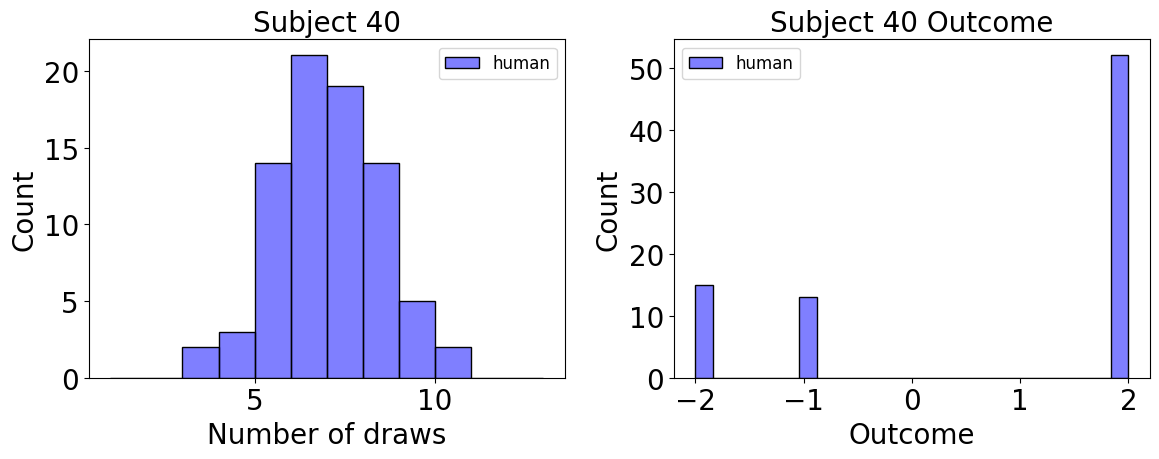

In [ ]:
from src.utils import load_config
is_latex = False
font_size = 20
config_dir = os.path.join(project_root, "data/simulation_configs")
n_instances = 200 # Adjust this to 10 or however many instances you need
# Load Questionnaire & Human Data
data_root_human = os.path.join(project_root, "data/TrHu_NHB_light/data_MEG")
betas_clean_human = pd.read_csv(os.path.join(data_root_human, 'glm_betas_human.csv'))
# Load Simulated Parameter Results & Configs
config_short_path = os.path.join(config_dir, "simulation_params_SBEXT-RP-C---.py")
config_long_path = os.path.join(config_dir, "simulation_params_LBEXT-RP-CL--.py")
config_short = load_config(config_short_path)
config_long = load_config(config_long_path)

results_df_short = pd.read_pickle(config_short.RESULTS_PATH)
results_df_long = pd.read_pickle(config_long.RESULTS_PATH)
param_order_short=config_short.PARAM_ORDER
param_order_long=config_long.PARAM_ORDER
param_ranges_long=config_long.PARAM_RANGES
param_ranges_short=config_short.PARAM_RANGES
# Assuming you already have:
long_params= np.array(list(results_df_long['fit_params_ga']))
short_params= np.array(list(results_df_short['fit_params_ga']))

# plot the correlation between the long_params vs short_params in scatter plot for each parameter in param_order_short
# set the axis limits with the max and min for each parameter for short axis in param_ranges_short and long axis in param_ranges_long

results_df_long['subject_ID']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Determine the number of parameters to plot
num_params = len(param_order_short)

# Create a figure with subplots
fig, axes = plt.subplots(1, num_params, figsize=(5 * num_params, 5))

# Ensure axes is iterable if there's only one parameter
if num_params == 1:
    axes = [axes]

for i, param_name in enumerate(param_order_short):
    ax = axes[i]
    
    # Get index for the short params
    idx_short = i
    
    # Check if this parameter also exists in the long configuration
    if param_name in param_order_long:
        idx_long = param_order_long.index(param_name)
        
        # Extract data for this parameter
        x_short = short_params[:, idx_short]
        y_long = long_params[:, idx_long]
        
        # Plot scatter
        ax.scatter(x_short, y_long, alpha=0.7, edgecolors='w', s=50)
        
        # Calculate Pearson correlation coefficient
        corr = np.corrcoef(x_short, y_long)[0, 1]
        
        # --- DYNAMIC AXIS LIMITS ---
        # Get actual min and max of the data
        x_min, x_max = x_short.min(), x_short.max()
        y_min, y_max = y_long.min(), y_long.max()
        
        # Calculate a 5% margin for aesthetic plotting
        x_margin = (x_max - x_min) * 0.05 if x_max != x_min else 0.1
        y_margin = (y_max - y_min) * 0.05 if y_max != y_min else 0.1
        
        # Set the limits
        ax.set_xlim(x_min - x_margin, x_max + x_margin)
        ax.set_ylim(y_min - y_margin, y_max + y_margin)
        # ---------------------------

        # --- REGRESSION LINE ---
        # Fit a 1st degree polynomial (linear regression: y = mx + b)
        slope, intercept = np.polyfit(x_short, y_long, 1)
        
        # Generate points for the line using the axis limits so it spans the whole plot
        x_line = np.array(ax.get_xlim())
        y_line = slope * x_line + intercept
        
        # Plot the regression line
        ax.plot(x_line, y_line, color='red', linewidth=2, linestyle='-', alpha=0.8)
        # -----------------------
        
        # Formatting
        ax.set_title(f"{param_name}\nr = {corr:.3f}", fontsize=font_size if 'font_size' in locals() else 14)
        ax.set_xlabel(f"{param_name} (Short)", fontsize=font_size if 'font_size' in locals() else 12)
        ax.set_ylabel(f"{param_name} (Long)", fontsize=font_size if 'font_size' in locals() else 12)
        
        ax.tick_params(axis='both', which='major', labelsize=font_size-4 if 'font_size' in locals() else 10)
        ax.grid(True, linestyle='--', alpha=0.5)
        
    else:
        # If the parameter from short_params is not in long_params
        ax.text(0.5, 0.5, f"{param_name}\nNot in long params", 
                ha='center', va='center', fontsize=font_size if 'font_size' in locals() else 12)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Added seaborn for the shaded regression


# Create a figure with subplots
fig, axes = plt.subplots(1, num_params, figsize=(5 * num_params, 5))

# Ensure axes is iterable if there's only one parameter
if num_params == 1:
    axes = [axes]

for i, param_name in enumerate(param_order_short):
    ax = axes[i]
    
    # Get index for the short params
    idx_short = i
    
    # Check if this parameter also exists in the long configuration
    if param_name in param_order_long:
        idx_long = param_order_long.index(param_name)
        
        # Extract data for this parameter
        x_short = short_params[:, idx_short]
        y_long = long_params[:, idx_long]
        
        # --- FILTER SPECIFIC PARAMETER ---
        if param_name == 'exaggeration_factor':
            # Create a mask to keep only subjects where the value is <= 2.5 
            valid_mask = (x_short <= 2.5) & (y_long <= 2.5)
            x_short = x_short[valid_mask]
            y_long = y_long[valid_mask]
        # ---------------------------------
        
        # Calculate Pearson correlation coefficient
        if len(x_short) > 1:
            corr = np.corrcoef(x_short, y_long)[0, 1]
        else:
            corr = np.nan
            
        # --- SEABORN REGPLOT (Scatter + Line + Shaded Variance) ---
        if len(x_short) > 1:
            sns.regplot(
                x=x_short, 
                y=y_long, 
                ax=ax, 
                scatter_kws={'alpha': 0.7, 'edgecolors': 'w', 's': 50}, 
                line_kws={'color': 'red', 'linewidth': 2, 'alpha': 0.8},
                ci=95 # 95% Confidence Interval (this is the default, but explicitly stated here)
            )
        elif len(x_short) == 1:
            # Fallback if only one point is left after filtering (can't draw regression)
            ax.scatter(x_short, y_long, alpha=0.7, edgecolors='w', s=50)
        # ----------------------------------------------------------
        
        # --- DYNAMIC AXIS LIMITS ---
        if len(x_short) > 0:
            # Get actual min and max of the filtered data
            x_min, x_max = x_short.min(), x_short.max()
            y_min, y_max = y_long.min(), y_long.max()
            
            # Calculate a 5% margin for aesthetic plotting
            x_margin = (x_max - x_min) * 0.05 if x_max != x_min else 0.1
            y_margin = (y_max - y_min) * 0.05 if y_max != y_min else 0.1
            
            # Set the limits
            ax.set_xlim(x_min - x_margin, x_max + x_margin)
            ax.set_ylim(y_min - y_margin, y_max + y_margin)
        # ---------------------------
        
        # Formatting
        ax.set_title(f"{param_name}\nr = {corr:.3f}", fontsize=font_size if 'font_size' in locals() else 14)
        ax.set_xlabel(f"{param_name} (Short)", fontsize=font_size if 'font_size' in locals() else 12)
        ax.set_ylabel(f"{param_name} (Long)", fontsize=font_size if 'font_size' in locals() else 12)
        
        ax.tick_params(axis='both', which='major', labelsize=font_size-4 if 'font_size' in locals() else 10)
        ax.grid(True, linestyle='--', alpha=0.5)
        
    else:
        # If the parameter from short_params is not in long_params
        ax.text(0.5, 0.5, f"{param_name}\nNot in long params", 
                ha='center', va='center', fontsize=font_size if 'font_size' in locals() else 12)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# # ============================================================
# # GLOBAL SUBJECT CONTRIBUTION ANALYSIS
# # RETURN AS DATAFRAME
# # ============================================================

# global_contribution_scores = []

# # ============================================================
# # LOOP THROUGH PARAMETERS
# # ============================================================

# for param_name in param_order_short:

#     # --------------------------------------------------------
#     # SKIP IF PARAM NOT IN LONG MODEL
#     # --------------------------------------------------------

#     if param_name not in param_order_long:
#         continue

#     # --------------------------------------------------------
#     # PARAMETER INDICES
#     # --------------------------------------------------------

#     idx_short = param_order_short.index(param_name)
#     idx_long = param_order_long.index(param_name)

#     # --------------------------------------------------------
#     # EXTRACT PARAMETER VALUES
#     # --------------------------------------------------------

#     x_short = short_params[:, idx_short]
#     y_long = long_params[:, idx_long]

#     subj_plot = subject_ids.copy()

#     # --------------------------------------------------------
#     # OPTIONAL FILTERING
#     # --------------------------------------------------------

#     if param_name == 'exaggeration_factor':

#         valid_mask = (
#             (x_short <= 2.5) &
#             (y_long <= 2.5)
#         )

#         x_short = x_short[valid_mask]
#         y_long = y_long[valid_mask]
#         subj_plot = subj_plot[valid_mask]

#     # ========================================================
#     # CORRELATION CONTRIBUTION SCORE
#     # ========================================================

#     contribution_score = (
#         (x_short - np.mean(x_short)) *
#         (y_long - np.mean(y_long))
#     )

#     # ========================================================
#     # DISTANCE TO DIAGONAL
#     # ========================================================

#     dist_to_diag = np.abs(y_long - x_short)

#     # ========================================================
#     # STORE PARAMETER-LEVEL DATA
#     # ========================================================

#     param_df = pd.DataFrame({

#         'subject_ID': subj_plot,

#         'parameter': param_name,

#         'x_short': x_short,

#         'y_long': y_long,

#         'contribution_score': contribution_score,

#         'positive_contributor': contribution_score > 0,

#         'distance_to_diagonal': dist_to_diag
#     })

#     global_contribution_scores.append(param_df)

# # ============================================================
# # CONCATENATE ALL PARAMETERS
# # ============================================================

# global_contribution_df = pd.concat(
#     global_contribution_scores,
#     ignore_index=True
# )

# # ============================================================
# # SUBJECT-LEVEL SUMMARY DATAFRAME
# # ============================================================

# subject_summary_df = (
#     global_contribution_df
#     .groupby('subject_ID')
#     .agg({

#         # Average covariance contribution
#         'contribution_score': 'mean',

#         # Number of positive contributions
#         'positive_contributor': 'sum',

#         # Average closeness to diagonal
#         'distance_to_diagonal': 'mean',

#         # Number of parameters analyzed
#         'parameter': 'count'
#     })
#     .rename(columns={

#         'contribution_score':
#             'mean_contribution_score',

#         'positive_contributor':
#             'n_positive_parameters',

#         'distance_to_diagonal':
#             'mean_distance_to_diagonal',

#         'parameter':
#             'n_total_parameters'
#     })
#     .reset_index()
# )

# # ============================================================
# # FRACTION OF POSITIVE CONTRIBUTIONS
# # ============================================================

# subject_summary_df[
#     'fraction_positive'
# ] = (
#     subject_summary_df['n_positive_parameters'] /
#     subject_summary_df['n_total_parameters']
# )

# # ============================================================
# # SORT BEST SUBJECTS
# # ============================================================

# subject_summary_df = (
#     subject_summary_df
#     .sort_values(
#         by=[
#             'fraction_positive',
#             'mean_contribution_score'
#         ],
#         ascending=False
#     )
#     .reset_index(drop=True)
# )

# # ============================================================
# # DISPLAY RESULTS
# # ============================================================

# print(subject_summary_df.head(20))

# # ============================================================
# # OPTIONAL SAVE
# # ============================================================

# save_dir = os.path.join(
#     project_root,
#     "results_subject_analysis"
# )

# os.makedirs(save_dir, exist_ok=True)

# subject_summary_df.to_csv(

#     os.path.join(
#         save_dir,
#         "global_subject_contribution_summary.csv"
#     ),

#     index=False
# )

# print("\nSaved:")
# print("global_subject_contribution_summary.csv")

# Spearman's rank correlation: 

In [ ]:
from src.utils import load_config

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# SETTINGS
# ============================================================

is_latex = False
font_size = 20

# Number of subjects to highlight
top_n = 10

config_dir = os.path.join(
    project_root,
    "data/simulation_configs"
)

# ============================================================
# LOAD HUMAN DATA
# ============================================================

data_root_human = os.path.join(
    project_root,
    "data/TrHu_NHB_light/data_MEG"
)

betas_clean_human = pd.read_csv(
    os.path.join(
        data_root_human,
        'glm_betas_human.csv'
    )
)

# ============================================================
# LOAD CONFIGS
# ============================================================

config_short_path = os.path.join(
    config_dir,
    "simulation_params_SBEXT-RP-C---.py"
)

config_long_path = os.path.join(
    config_dir,
    "simulation_params_LBE-T-RP-CL--.py"
)

config_short = load_config(
    config_short_path
)

config_long = load_config(
    config_long_path
)

# ============================================================
# LOAD RESULTS
# ============================================================

results_df_short = pd.read_pickle(
    config_short.RESULTS_PATH
)

results_df_long = pd.read_pickle(
    config_long.RESULTS_PATH
)

param_order_short = config_short.PARAM_ORDER
param_order_long = config_long.PARAM_ORDER

param_ranges_short = config_short.PARAM_RANGES
param_ranges_long = config_long.PARAM_RANGES

# ============================================================
# ALIGN SUBJECTS USING subject_ID
# ============================================================

common_subjects = np.intersect1d(
    results_df_short['subject_ID'].values,
    results_df_long['subject_ID'].values
)

results_df_short_aligned = (
    results_df_short[
        results_df_short['subject_ID'].isin(
            common_subjects
        )
    ]
    .sort_values('subject_ID')
    .reset_index(drop=True)
)

results_df_long_aligned = (
    results_df_long[
        results_df_long['subject_ID'].isin(
            common_subjects
        )
    ]
    .sort_values('subject_ID')
    .reset_index(drop=True)
)

assert np.all(
    results_df_short_aligned[
        'subject_ID'
    ].values
    ==
    results_df_long_aligned[
        'subject_ID'
    ].values
), "Subject ordering mismatch!"

subject_ids = (
    results_df_short_aligned[
        'subject_ID'
    ].values
)

# ============================================================
# EXTRACT PARAMETER ARRAYS
# ============================================================

short_params = np.array(
    list(
        results_df_short_aligned[
            'fit_params_ga'
        ]
    )
)

long_params = np.array(
    list(
        results_df_long_aligned[
            'fit_params_ga'
        ]
    )
)

# ============================================================
# STORE RESULTS
# ============================================================

closest_subjects_all = {}
correlation_subjects_all = {}

# ============================================================
# PLOTTING
# ============================================================

num_params = len(param_order_short)

fig, axes = plt.subplots(
    1,
    num_params,
    figsize=(5 * num_params, 5)
)

if num_params == 1:
    axes = [axes]

# ============================================================
# LOOP THROUGH PARAMETERS
# ============================================================

for i, param_name in enumerate(
    param_order_short
):

    ax = axes[i]

    # --------------------------------------------------------
    # CHECK PARAM EXISTS IN LONG MODEL
    # --------------------------------------------------------

    if param_name not in param_order_long:

        ax.text(
            0.5,
            0.5,
            f"{param_name}\nNot in long params",
            ha='center',
            va='center',
            fontsize=font_size
        )

        ax.axis('off')
        continue

    # --------------------------------------------------------
    # PARAMETER INDICES
    # --------------------------------------------------------

    idx_short = (
        param_order_short.index(
            param_name
        )
    )

    idx_long = (
        param_order_long.index(
            param_name
        )
    )

    # --------------------------------------------------------
    # EXTRACT DATA
    # --------------------------------------------------------

    x_short = short_params[:, idx_short]
    y_long = long_params[:, idx_long]

    subj_plot = subject_ids.copy()

    # --------------------------------------------------------
    # OPTIONAL FILTERING
    # --------------------------------------------------------

    if param_name == (
        'exaggeration_factor'
    ):

        valid_mask = (
            (x_short <= 2.5)
            &
            (y_long <= 2.5)
        )

        x_short = x_short[
            valid_mask
        ]

        y_long = y_long[
            valid_mask
        ]

        subj_plot = subj_plot[
            valid_mask
        ]

    # ========================================================
    # APPROACH 1:
    # SUBJECTS CLOSEST TO DIAGONAL
    # ========================================================

    dist_to_diag = np.abs(
        y_long - x_short
    )

    sorted_diag_idx = np.argsort(
        dist_to_diag
    )

    closest_subjects = pd.DataFrame({
        'subject_ID':
            subj_plot[
                sorted_diag_idx[:top_n]
            ],

        'x_short':
            x_short[
                sorted_diag_idx[:top_n]
            ],

        'y_long':
            y_long[
                sorted_diag_idx[:top_n]
            ],

        'distance_to_diagonal':
            dist_to_diag[
                sorted_diag_idx[:top_n]
            ]
    })

    closest_subjects_all[
        param_name
    ] = closest_subjects

    print("\n" + "=" * 60)
    print(
        f"CLOSEST TO DIAGONAL: "
        f"{param_name}"
    )
    print("=" * 60)
    print(closest_subjects)

    # ========================================================
    # APPROACH 2:
    # SUBJECTS CONTRIBUTING MOST TO
    # SPEARMAN CORRELATION
    # ========================================================

    x_rank = (
        pd.Series(
            x_short
        )
        .rank()
        .values
    )

    y_rank = (
        pd.Series(
            y_long
        )
        .rank()
        .values
    )

    contribution_score = (
        (x_rank - np.mean(x_rank))
        *
        (y_rank - np.mean(y_rank))
    )

    sorted_corr_idx = np.argsort(
        contribution_score
    )[::-1]

    correlation_subjects = (
        pd.DataFrame({
            'subject_ID':
                subj_plot[
                    sorted_corr_idx[:top_n]
                ],

            'x_short':
                x_short[
                    sorted_corr_idx[:top_n]
                ],

            'y_long':
                y_long[
                    sorted_corr_idx[:top_n]
                ],

            'x_rank':
                x_rank[
                    sorted_corr_idx[:top_n]
                ],

            'y_rank':
                y_rank[
                    sorted_corr_idx[:top_n]
                ],

            'spearman_contribution':
                contribution_score[
                    sorted_corr_idx[:top_n]
                ]
        })
    )

    correlation_subjects_all[
        param_name
    ] = correlation_subjects

    print("\n" + "=" * 60)

    print(
        "LARGEST POSITIVE "
        "SPEARMAN CONTRIBUTORS: "
        f"{param_name}"
    )

    print("=" * 60)
    print(correlation_subjects)

    # --------------------------------------------------------
    # SCATTER PLOT
    # --------------------------------------------------------

    ax.scatter(
        x_short,
        y_long,
        alpha=0.7,
        edgecolors='w',
        s=70
    )

    # ========================================================
    # LABEL CLOSEST TO DIAGONAL (GREEN)
    # ========================================================

    for idx in (
        sorted_diag_idx[:top_n]
    ):

        ax.text(
            x_short[idx],
            y_long[idx],
            str(
                subj_plot[idx]
            ),
            fontsize=8,
            color='green'
        )

    # ========================================================
    # LABEL TOP SPEARMAN CONTRIBUTORS
    # (RED)
    # ========================================================

    for idx in (
        sorted_corr_idx[:top_n]
    ):

        ax.text(
            x_short[idx],
            y_long[idx],
            str(
                subj_plot[idx]
            ),
            fontsize=8,
            color='red'
        )

    # --------------------------------------------------------
    # SPEARMAN CORRELATION
    # --------------------------------------------------------

    if len(x_short) > 1:

        corr, p_value = (
            spearmanr(
                x_short,
                y_long
            )
        )

    else:

        corr = np.nan
        p_value = np.nan

    # --------------------------------------------------------
    # AXIS LIMITS
    # --------------------------------------------------------

    if (
        param_name
        in
        param_ranges_short
    ):

        x_limits = (
            param_ranges_short[
                param_name
            ]
        )

        ax.set_xlim(
            x_limits
        )

    if (
        param_name
        in
        param_ranges_long
    ):

        y_limits = (
            param_ranges_long[
                param_name
            ]
        )

        ax.set_ylim(
            y_limits
        )

    # --------------------------------------------------------
    # REGRESSION LINE
    # (visual only; unchanged)
    # --------------------------------------------------------

    if len(x_short) > 1:

        slope, intercept = (
            np.polyfit(
                x_short,
                y_long,
                1
            )
        )

        x_line = np.array(
            ax.get_xlim()
        )

        y_line = (
            slope * x_line
            +
            intercept
        )

        ax.plot(
            x_line,
            y_line,
            color='red',
            linewidth=2,
            linestyle='-',
            alpha=0.8
        )

    # --------------------------------------------------------
    # IDENTITY LINE
    # --------------------------------------------------------

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    line_min = min(
        xlim[0],
        ylim[0]
    )

    line_max = max(
        xlim[1],
        ylim[1]
    )

    ax.plot(
        [line_min, line_max],
        [line_min, line_max],
        linestyle='--',
        linewidth=1.5,
        alpha=0.6
    )

    # --------------------------------------------------------
    # FORMATTING
    # --------------------------------------------------------

    ax.set_title(
        (
            f"{param_name}\n"
            f"Spearman ρ = "
            f"{corr:.3f}\n"
            f"p = "
            f"{p_value:.3g}"
        ),
        fontsize=font_size
    )

    ax.set_xlabel(
        f"{param_name} "
        f"(Short)",
        fontsize=font_size
    )

    ax.set_ylabel(
        f"{param_name} "
        f"(Long)",
        fontsize=font_size
    )

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=font_size - 4
    )

    ax.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

# ============================================================
# FINALIZE
# ============================================================

plt.tight_layout()
plt.show()

# ============================================================
# SAVE RESULTS TO CSV
# ============================================================

save_dir = os.path.join(
    project_root,
    "results_subject_analysis"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

for (
    param_name,
    df
) in closest_subjects_all.items():

    df.to_csv(
        os.path.join(
            save_dir,
            f"{param_name}"
            "_closest_to_diagonal.csv"
        ),
        index=False
    )

for (
    param_name,
    df
) in (
    correlation_subjects_all
    .items()
):

    df.to_csv(
        os.path.join(
            save_dir,
            f"{param_name}"
            "_top_spearman_contributors.csv"
        ),
        index=False
    )

print(
    "\nSaved subject "
    "analysis tables."
)

# ============================================================
# LOAD ENSEMBLE DATA
# ============================================================

ensemble_save_path_short = os.path.join(
    config_short.DATA_PATH,
    "ensemble_distribution_data.pkl"
)

ensemble_data_short = pd.read_pickle(
    ensemble_save_path_short
)

ensemble_save_path_long = os.path.join(
    config_long.DATA_PATH,
    "ensemble_distribution_data.pkl"
)

ensemble_data_long = pd.read_pickle(
    ensemble_save_path_long
)

metrics_save_path_short = os.path.join(
    config_short.DATA_PATH,
    "ensemble_metrics_summary.csv"
)

metrics_save_path_long = os.path.join(
    config_long.DATA_PATH,
    "ensemble_metrics_summary.csv"
)

metrics_df_short = pd.read_csv(
    metrics_save_path_short
)

metrics_df_long = pd.read_csv(
    metrics_save_path_long
)


def plot_subject_short_vs_long(
    target_id,
    ensemble_data_short,
    ensemble_data_long,
    metrics_df_short,
    metrics_df_long
):
    """
    Compare short vs long horizon
    ensemble distributions
    for the same subject.
    """

    data_short = (
        ensemble_data_short.get(
            target_id
        )
    )

    data_long = (
        ensemble_data_long.get(
            target_id
        )
    )

    if data_short is None:

        print(
            f"User {target_id} "
            "not found in SHORT "
            "ensemble data."
        )
        return

    if data_long is None:

        print(
            f"User {target_id} "
            "not found in LONG "
            "ensemble data."
        )
        return

    metrics_short = (
        metrics_df_short[
            metrics_df_short[
                'userID'
            ]
            ==
            target_id
        ]
        .iloc[0]
    )

    metrics_long = (
        metrics_df_long[
            metrics_df_long[
                'userID'
            ]
            ==
            target_id
        ]
        .iloc[0]
    )

    r2_short = (
        metrics_short[
            'r2_draws'
        ]
    )

    r2_long = (
        metrics_long[
            'r2_draws'
        ]
    )

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(16, 6)
    )

    # SHORT
    x_short = np.arange(
        len(
            data_short[
                'human_counts'
            ]
        )
    )

    ax1.bar(
        x_short,
        data_short[
            'human_counts'
        ],
        alpha=0.5,
        color='gray',
        label='Human Data'
    )

    ax1.errorbar(
        x_short,
        data_short[
            'avg_sim_counts'
        ],
        yerr=data_short[
            'std_sim_counts'
        ],
        fmt='-o',
        color='blue',
        capsize=4,
        label='Ensemble Sim Avg ± Std'
    )

    ax1.set_title(
        (
            f"Subject "
            f"{target_id}: "
            f"SHORT Horizon\n"
            f"Mean R² = "
            f"{r2_short:.3f}"
        )
    )

    ax1.grid(alpha=0.3)
    ax1.legend()

    # LONG
    x_long = np.arange(
        len(
            data_long[
                'human_counts'
            ]
        )
    )

    ax2.bar(
        x_long,
        data_long[
            'human_counts'
        ],
        alpha=0.5,
        color='gray',
        label='Human Data'
    )

    ax2.errorbar(
        x_long,
        data_long[
            'avg_sim_counts'
        ],
        yerr=data_long[
            'std_sim_counts'
        ],
        fmt='-o',
        color='orange',
        capsize=4,
        label='Ensemble Sim Avg ± Std'
    )

    ax2.set_title(
        (
            f"Subject "
            f"{target_id}: "
            f"LONG Horizon\n"
            f"Mean R² = "
            f"{r2_long:.3f}"
        )
    )

    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# load the ensemble data and metrics_df for each long and short files 
ensemble_save_path_short = os.path.join(config_short.DATA_PATH, "ensemble_distribution_data.pkl")
ensemble_data_short = pd.read_pickle(ensemble_save_path_short)

ensemble_save_path_long = os.path.join(config_long.DATA_PATH, "ensemble_distribution_data.pkl")
ensemble_data_long = pd.read_pickle(ensemble_save_path_long)

metrics_save_path_short = os.path.join(config_short.DATA_PATH, "ensemble_metrics_summary.csv")
metrics_save_path_long = os.path.join(config_long.DATA_PATH, "ensemble_metrics_summary.csv")

metrics_df_short = pd.read_csv(metrics_save_path_short)
metrics_df_long = pd.read_csv(metrics_save_path_long)


In [ ]:
def plot_subject_short_vs_long_custom(
    target_id,
    ensemble_data_short,
    ensemble_data_long,
    metrics_df_short,
    metrics_df_long,
    short_bins=8,
    long_bins=14,
    show_simulation=True,
    show_outcomes=True,
    path=None,
):
    """
    Compare short vs long horizon ensemble distributions for the same subject.

    Layout when show_outcomes=True (2x2):
    -----------------------------------------------
    | Draws Short   | Outcomes Short  |  (top row)
    | Draws Long    | Outcomes Long   |  (bottom row)
    -----------------------------------------------

    Layout when show_outcomes=False (2x1):
    -------------------
    | Draws Short     |
    | Draws Long      |
    -------------------

    A single shared legend is placed below all panels.
    If path is given, saves <path>/subject_<target_id>.pdf/svg/png.

    Parameters
    ----------
    show_simulation : bool
        If True, overlay ensemble simulation mean ± std on top of human data.
        If False, plot only human data bars.
    show_outcomes : bool
        If True, include outcome panels alongside draws panels.
        If False, show only draw panels.
    short_bins : int
        Number of draw bins to show for short horizon.
    long_bins : int
        Number of draw bins to show for long horizon.
    path : str or None
        Directory to save figures. If None, figure is only shown.
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    # ========================================================
    # LOAD SUBJECT DATA
    # ========================================================

    data_short = ensemble_data_short.get(target_id)
    data_long  = ensemble_data_long.get(target_id)

    if data_short is None:
        print(f"User {target_id} not found in SHORT ensemble data.")
        return

    if data_long is None:
        print(f"User {target_id} not found in LONG ensemble data.")
        return

    # ========================================================
    # EXTRACT METRICS
    # ========================================================

    metrics_short = metrics_df_short[metrics_df_short['userID'] == target_id].iloc[0]
    metrics_long  = metrics_df_long[metrics_df_long['userID'] == target_id].iloc[0]

    r2_draws_short   = metrics_short['r2_draws']
    r2_draws_long    = metrics_long['r2_draws']
    r2_outcome_short = metrics_short['r2_outcome']
    r2_outcome_long  = metrics_long['r2_outcome']

    # ========================================================
    # PREPARE DRAW DATA (FORCE BIN COUNT)
    # ========================================================

    def prepare_array(arr, n_bins):
        arr = np.asarray(arr)
        if len(arr) >= n_bins:
            return arr[:n_bins]
        padded = np.zeros(n_bins)
        padded[:len(arr)] = arr
        return padded

    human_counts_short   = prepare_array(data_short['human_counts'],  short_bins)
    avg_sim_counts_short = prepare_array(data_short['avg_sim_counts'], short_bins)
    std_sim_counts_short = prepare_array(data_short['std_sim_counts'], short_bins)
    x_short = np.arange(short_bins)

    human_counts_long    = prepare_array(data_long['human_counts'],   long_bins)
    avg_sim_counts_long  = prepare_array(data_long['avg_sim_counts'],  long_bins)
    std_sim_counts_long  = prepare_array(data_long['std_sim_counts'],  long_bins)
    x_long = np.arange(long_bins)

    valid_indices  = [0, 1, 4]
    outcome_labels = [-2, -1, 2]
    x_outcomes     = np.arange(len(outcome_labels))

    # ========================================================
    # CREATE FIGURE
    # 2x2 when show_outcomes=True, 2x1 when False
    # ========================================================

    ncols = 2 if show_outcomes else 1
    fig_width = 16 if show_outcomes else 10
    fig, axs = plt.subplots(2, ncols, figsize=(fig_width, 10))

    if show_outcomes:
        ax_draws_short, ax_out_short = axs[0]
        ax_draws_long,  ax_out_long  = axs[1]
    else:
        ax_draws_short = axs[0]
        ax_draws_long  = axs[1]

    # ── helper: draw one panel (no per-axis legend) ───────────────────────────
    def _draw_panel(ax, x, human, avg_sim, std_sim, color, title, xlabel,
                    xtick_labels=None):
        ax.bar(x, human, alpha=0.5, color='gray')
        if show_simulation:
            ax.errorbar(
                x, avg_sim, yerr=std_sim,
                fmt='-o', color=color, capsize=4,
            )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_xticks(x)
        if xtick_labels is not None:
            ax.set_xticklabels(xtick_labels)
        ax.grid(alpha=0.3)

    # ── Short horizon (top row) ───────────────────────────────────────────────
    _draw_panel(
        ax_draws_short,
        x_short,
        human_counts_short,
        avg_sim_counts_short,
        std_sim_counts_short,
        color='blue',
        title=f"Subject {target_id}: SHORT Horizon Draws",
        xlabel="Number of Draws",
    )

    if show_outcomes:
        h_out_short   = data_short['human_outcomes'][valid_indices]
        avg_out_short = data_short['avg_sim_outcomes'][valid_indices]
        std_out_short = data_short['std_sim_outcomes'][valid_indices]

        _draw_panel(
            ax_out_short,
            x_outcomes,
            h_out_short,
            avg_out_short,
            std_out_short,
            color='blue',
            title=f"Subject {target_id}: SHORT Horizon Outcomes",
            xlabel="Outcome Value",
            xtick_labels=outcome_labels,
        )

    # ── Long horizon (bottom row) ─────────────────────────────────────────────
    _draw_panel(
        ax_draws_long,
        x_long,
        human_counts_long,
        avg_sim_counts_long,
        std_sim_counts_long,
        color='orange',
        title=f"Subject {target_id}: LONG Horizon Draws",
        xlabel="Number of Draws (t)",
    )

    if show_outcomes:
        h_out_long   = data_long['human_outcomes'][valid_indices]
        avg_out_long = data_long['avg_sim_outcomes'][valid_indices]
        std_out_long = data_long['std_sim_outcomes'][valid_indices]

        _draw_panel(
            ax_out_long,
            x_outcomes,
            h_out_long,
            avg_out_long,
            std_out_long,
            color='orange',
            title=f"Subject {target_id}: LONG Horizon Outcomes",
            xlabel="Outcome Value",
            xtick_labels=outcome_labels,
        )

    # ========================================================
    # SHARED LEGEND (below all panels, one entry per concept)
    # ========================================================

    if show_simulation:
        legend_elements = [
            Patch(facecolor='gray', alpha=0.5, label='Human Data'),
            Line2D([0], [0], color='blue',   marker='o', label='Sim Short Avg \u00b1 Std'),
            Line2D([0], [0], color='orange', marker='o', label='Sim Long Avg \u00b1 Std'),
        ]
        ncol = 3
    else:
        legend_elements = [
            Patch(facecolor='gray', alpha=0.5, label='Human Data'),
        ]
        ncol = 1

    # fig.legend(
    #     handles=legend_elements,
    #     loc='lower center',
    #     ncol=ncol,
    #     fontsize=12,
    #     frameon=True,
    # )
    fig.legend(loc='upper right')

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.10)

    # ========================================================
    # SAVE
    # ========================================================

    if path is not None:
        os.makedirs(path, exist_ok=True)
        base = os.path.join(path, f"subject_{target_id}")
        fig.savefig(base + ".pdf",          bbox_inches='tight')
        fig.savefig(base + ".svg",          bbox_inches='tight')
        fig.savefig(base + ".png", dpi=600, bbox_inches='tight')

    plt.show()


In [ ]:
def plot_subject_short_vs_long_custom(
    target_id,
    ensemble_data_short,
    ensemble_data_long,
    metrics_df_short,
    metrics_df_long,
    short_bins=8,
    long_bins=14,
    show_simulation=True,
    show_outcomes=True,
    path=None,
):
    """
    Compare short and long horizon distributions for the same subject,
    overlaid on the same panel(s).

    Layout when show_outcomes=True  → 1 row × 2 columns
        | Draws (short + long)  |  Outcomes (short + long) |
    Layout when show_outcomes=False → single panel
        | Draws (short + long) |

    Short horizon : steel-blue  (#2166AC)
    Long horizon  : coral-red   (#D6604D)
    Both bars are semi-transparent so overlap is visible.

    If path is given, saves <path>/subject_<target_id>.pdf/svg/png.
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    # Horizon colours (colorblind-safe, PLoS CB-friendly)
    C_SHORT      = '#2166AC'   # steel blue
    C_LONG       = '#D6604D'   # coral red
    C_SHORT_SIM  = '#053061'   # dark navy  (sim line for short)
    C_LONG_SIM   = '#67001F'   # dark crimson (sim line for long)
    BAR_ALPHA    = 0.55

    # ── Load data ─────────────────────────────────────────────────────────────
    data_short = ensemble_data_short.get(target_id)
    data_long  = ensemble_data_long.get(target_id)

    if data_short is None:
        print(f"User {target_id} not found in SHORT ensemble data.")
        return
    if data_long is None:
        print(f"User {target_id} not found in LONG ensemble data.")
        return

    # ── Metrics ───────────────────────────────────────────────────────────────
    ms = metrics_df_short[metrics_df_short['userID'] == target_id].iloc[0]
    ml = metrics_df_long[metrics_df_long['userID']  == target_id].iloc[0]

    r2_draws_short   = ms['r2_draws']
    r2_draws_long    = ml['r2_draws']
    r2_outcome_short = ms['r2_outcome']
    r2_outcome_long  = ml['r2_outcome']

    # ── Prepare arrays ────────────────────────────────────────────────────────
    def _pad(arr, n):
        arr = np.asarray(arr, dtype=float)
        if len(arr) >= n:
            return arr[:n]
        out = np.zeros(n)
        out[:len(arr)] = arr
        return out

    # Draws: align both to long_bins so x-axis is shared
    n_bins = long_bins
    hc_s  = _pad(data_short['human_counts'],   n_bins)
    as_s  = _pad(data_short['avg_sim_counts'],  n_bins)
    ss_s  = _pad(data_short['std_sim_counts'],  n_bins)

    hc_l  = _pad(data_long['human_counts'],    n_bins)
    as_l  = _pad(data_long['avg_sim_counts'],   n_bins)
    ss_l  = _pad(data_long['std_sim_counts'],   n_bins)

    x = np.arange(n_bins)

    # Outcomes
    valid_indices  = [0, 1, 4]
    outcome_labels = [-2, -1, 2]
    x_out = np.arange(len(outcome_labels))
    bar_w = 0.35   # side-by-side grouped bars for outcomes

    ho_s  = data_short['human_outcomes'][valid_indices]
    ao_s  = data_short['avg_sim_outcomes'][valid_indices]
    so_s  = data_short['std_sim_outcomes'][valid_indices]

    ho_l  = data_long['human_outcomes'][valid_indices]
    ao_l  = data_long['avg_sim_outcomes'][valid_indices]
    so_l  = data_long['std_sim_outcomes'][valid_indices]

    # ── Figure layout ─────────────────────────────────────────────────────────
    ncols     = 2 if show_outcomes else 1
    fig_w     = 16 if show_outcomes else 8
    fig, axs  = plt.subplots(1, ncols, figsize=(fig_w, 5))
    ax_draws  = axs[0] if show_outcomes else axs
    ax_out    = axs[1] if show_outcomes else None

    # ── Draws panel ───────────────────────────────────────────────────────────
    ax_draws.bar(x, hc_s, color=C_SHORT, alpha=BAR_ALPHA, label='Human Short')
    ax_draws.bar(x, hc_l, color=C_LONG,  alpha=BAR_ALPHA, label='Human Long')

    if show_simulation:
        ax_draws.errorbar(x, as_s, yerr=ss_s, fmt='-o',
                          color=C_SHORT_SIM, capsize=3, linewidth=1.5,
                          label='Sim Short \u00b1 Std')
        ax_draws.errorbar(x, as_l, yerr=ss_l, fmt='-s',
                          color=C_LONG_SIM,  capsize=3, linewidth=1.5,
                          label='Sim Long \u00b1 Std')

    ax_draws.set_title(
        f"Subject {target_id}: Decision Time Distribution\n",
        # f"R\u00b2 short={r2_draws_short:.3f}, long={r2_draws_long:.3f}",
        fontsize=13
    )
    ax_draws.set_xlabel("Number of Draws", fontsize=12)
    ax_draws.set_ylabel("Count", fontsize=12)
    ax_draws.set_xticks(x)
    ax_draws.grid(alpha=0.3)

    # ── Outcomes panel (grouped bars) ─────────────────────────────────────────
    if show_outcomes and ax_out is not None:
        ax_out.bar(x_out - bar_w/2, ho_s, width=bar_w,
                   color=C_SHORT, alpha=BAR_ALPHA, label='Human Short')
        ax_out.bar(x_out + bar_w/2, ho_l, width=bar_w,
                   color=C_LONG,  alpha=BAR_ALPHA, label='Human Long')

        if show_simulation:
            ax_out.errorbar(x_out - bar_w/2, ao_s, yerr=so_s,
                            fmt='o', color=C_SHORT_SIM, capsize=3,
                            linestyle='none', label='Sim Short \u00b1 Std')
            ax_out.errorbar(x_out + bar_w/2, ao_l, yerr=so_l,
                            fmt='s', color=C_LONG_SIM,  capsize=3,
                            linestyle='none', label='Sim Long \u00b1 Std')

        ax_out.set_title(
            f"Subject {target_id}: Outcomes\n"
            f"R\u00b2 short={r2_outcome_short:.3f}, long={r2_outcome_long:.3f}",
            fontsize=13
        )
        ax_out.set_xlabel("Outcome", fontsize=12)
        ax_out.set_ylabel("Count", fontsize=12)
        ax_out.set_xticks(x_out)
        ax_out.set_xticklabels(outcome_labels)
        ax_out.grid(alpha=0.3)
    # plot vertical dashed line to show the hazard onset for the long horizon starts at draw=10 
    ax_draws.axvline(x=10, color='red', linestyle='--', alpha=0.7)
    # make the label on the line written instead of in the legend and rotate it vertically
    # ax_draws.text(10, ax_draws.get_ylim()[1]*0.9, 'Long Hazard Onset', color='red', rotation=90, va='top', ha='right', fontsize=10)
    # add vertical line for the short horizon at draw=4
    ax_draws.axvline(x=4, color='blue', linestyle='--', alpha=0.7)
    # ax_draws.text(4, ax_draws.get_ylim()[1]*0.9, 'Short Hazard Onset', color='blue', rotation=90, va='top', ha='right', fontsize=10)
    # ── Shared legend ─────────────────────────────────────────────────────────
    if show_simulation:
        legend_handles = [
            Patch(facecolor=C_SHORT, alpha=BAR_ALPHA, label='Human Short'),
            Patch(facecolor=C_LONG,  alpha=BAR_ALPHA, label='Human Long'),
            Line2D([0],[0], color=C_SHORT_SIM, marker='o', label='Sim Short \u00b1 Std'),
            Line2D([0],[0], color=C_LONG_SIM,  marker='s', label='Sim Long \u00b1 Std'),
        ]
        ncol_leg = 4
    else:
        legend_handles = [
            Patch(facecolor=C_SHORT, alpha=BAR_ALPHA, label='Short Horizon'),
            Patch(facecolor=C_LONG,  alpha=BAR_ALPHA, label='Long Horizon'),
        ]
        ncol_leg = 2

    # fig.legend(handles=legend_handles, loc='lower center', ncol=ncol_leg,
            #    fontsize=11, frameon=True)
    # 
    fig.legend(loc='upper right',fontsize=11)
    

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18)

    # ── Save ──────────────────────────────────────────────────────────────────
    if path is not None:
        os.makedirs(path, exist_ok=True)
        base = os.path.join(path, f"subject_{target_id}")
        fig.savefig(base + ".pdf",          bbox_inches='tight')
        fig.savefig(base + ".svg",          bbox_inches='tight')
        fig.savefig(base + ".png", dpi=600, bbox_inches='tight')

    plt.show()


In [ ]:
def plot_multi_subjects_panel(
    subject_ids,
    ensemble_data_short,
    ensemble_data_long,
    metrics_df_short,
    metrics_df_long,
    short_bins=8,
    long_bins=14,
    show_simulation=True,
    show_outcomes=False,
    panel_labels=None,
    path=None,
    filename="four_subjects_panel",
):
    """
    Plot multiple subjects in a single figure, each subject in one panel.

    Subjects are arranged in a 2×2 grid (left-to-right, top-to-bottom).
    Short and long horizon distributions are overlaid in each panel.
    One shared legend is placed below all panels.

    Parameters
    ----------
    subject_ids   : list of subject IDs, length must be 4 (for 2×2) or 2 (for 1×2)
    show_simulation : bool  — overlay ensemble sim mean ± std
    show_outcomes   : bool  — add outcomes sub-panel per subject (makes layout wider)
    panel_labels  : list of str or None — e.g. ['A','B','C','D']
    path          : directory to save figure; None = show only
    filename      : base filename (without extension)
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    # ── colours ──────────────────────────────────────────────────────────────
    C_SHORT     = '#eb6834'
    C_LONG      = '#4a3aa7'
    C_SHORT_SIM = '#a8431a'
    C_LONG_SIM  = '#2f2470'
    BAR_ALPHA   = 0.55

    if panel_labels is None:
        panel_labels = [chr(97 + i) for i in range(len(subject_ids))]  # a,b,c,d...

    n = len(subject_ids)
    ncols_grid = 2
    nrows_grid = (n + 1) // 2
    fig_w = 16 * (2 if show_outcomes else 1)
    fig_h = 4.5 * nrows_grid + 1.2   # extra room for legend

    fig, axes = plt.subplots(nrows_grid, ncols_grid,
                             figsize=(fig_w, fig_h),
                             squeeze=False)

    def _pad(arr, n_bins):
        arr = np.asarray(arr, dtype=float)
        if len(arr) >= n_bins:
            return arr[:n_bins]
        out = np.zeros(n_bins)
        out[:len(arr)] = arr
        return out

    x = np.arange(long_bins)
    valid_indices  = [0, 1, 4]
    outcome_labels_tick = [-2, -1, 2]
    x_out = np.arange(len(outcome_labels_tick))
    bar_w = 0.35

    for panel_idx, (sid, label) in enumerate(zip(subject_ids, panel_labels)):
        row = panel_idx // ncols_grid
        col = panel_idx %  ncols_grid
        ax  = axes[row][col]

        data_s = ensemble_data_short.get(sid)
        data_l = ensemble_data_long.get(sid)

        if data_s is None or data_l is None:
            ax.set_title(f"Subject {sid} — data missing", fontsize=12)
            ax.text(-0.09, 1.14, f"({label})", transform=ax.transAxes,
                    fontsize=15, fontweight="bold", va="top", ha="right")
            ax.axis('off')
            continue

        hc_s = _pad(data_s['human_counts'],   long_bins)
        as_s = _pad(data_s['avg_sim_counts'],  long_bins)
        ss_s = _pad(data_s['std_sim_counts'],  long_bins)

        hc_l = _pad(data_l['human_counts'],   long_bins)
        as_l = _pad(data_l['avg_sim_counts'],  long_bins)
        ss_l = _pad(data_l['std_sim_counts'],  long_bins)

        ax.bar(x - bar_w/2, hc_s, width=bar_w, color=C_SHORT, alpha=BAR_ALPHA)
        ax.bar(x + bar_w/2, hc_l, width=bar_w, color=C_LONG,  alpha=BAR_ALPHA)

        if show_simulation:
            ax.errorbar(x - bar_w/2, as_s, yerr=ss_s, fmt='-o',
                        color=C_SHORT_SIM, capsize=3, linewidth=1.5)
            ax.errorbar(x + bar_w/2, as_l, yerr=ss_l, fmt='-s',
                        color=C_LONG_SIM,  capsize=3, linewidth=1.5)

        # Hazard onset markers
        ax.axvline(x=9,  color=C_LONG,  linestyle='--', alpha=0.7, linewidth=1.2)
        ax.axvline(x=3,  color=C_SHORT, linestyle='--', alpha=0.7, linewidth=1.2)

        ax.set_title(f"Subject {sid}", fontsize=13, fontweight='bold')
        # panel letter outside the axes, matching the convention used by the
        # other multi-panel figures rather than sitting inside the title
        ax.text(-0.09, 1.14, f"({label})", transform=ax.transAxes,
                fontsize=15, fontweight="bold", va="top", ha="right")
        ax.set_xlabel("Number of Draws", fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.set_xticks(x)
        ax.grid(alpha=0.3)

    # Hide any unused axes (if n < nrows*ncols)
    for panel_idx in range(n, nrows_grid * ncols_grid):
        row = panel_idx // ncols_grid
        col = panel_idx %  ncols_grid
        axes[row][col].set_visible(False)

    # ── shared legend ─────────────────────────────────────────────────────────
    if show_simulation:
        handles = [
            Patch(facecolor=C_SHORT, alpha=BAR_ALPHA, label='Human — Short Horizon'),
            Patch(facecolor=C_LONG,  alpha=BAR_ALPHA, label='Human — Long Horizon'),
            Line2D([0],[0], color=C_SHORT_SIM, marker='o', label='Sim Short \u00b1 Std'),
            Line2D([0],[0], color=C_LONG_SIM,  marker='s', label='Sim Long \u00b1 Std'),
        ]
        ncol_leg = 4
    else:
        handles = [
            Patch(facecolor=C_SHORT, alpha=BAR_ALPHA, label='Short Horizon'),
            Patch(facecolor=C_LONG,  alpha=BAR_ALPHA, label='Long Horizon'),
            Line2D([0],[0], color=C_SHORT, linestyle='--', alpha=0.7, label='Short Hazard Onset'),
            Line2D([0],[0], color=C_LONG,  linestyle='--', alpha=0.7, label='Long Hazard Onset'),
        ]
        ncol_leg = 4

    fig.legend(handles=handles, loc='lower center', ncol=ncol_leg,
               fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)

    # ── save ──────────────────────────────────────────────────────────────────
    if path is not None:
        os.makedirs(path, exist_ok=True)
        base = os.path.join(path, filename)
        fig.savefig(base + ".pdf",          bbox_inches='tight')
        fig.savefig(base + ".svg",          bbox_inches='tight')
        fig.savefig(base + ".png", dpi=600, bbox_inches='tight')

    plt.show()


# ── Call ──────────────────────────────────────────────────────────────────────
plot_multi_subjects_panel(
    subject_ids=[6, 10, 53, 88],
    ensemble_data_short=ensemble_data_short,
    ensemble_data_long=ensemble_data_long,
    metrics_df_short=metrics_df_short,
    metrics_df_long=metrics_df_long,
    short_bins=8,
    long_bins=14,
    show_outcomes=False,
    show_simulation=False,
    path='../figures/POMDP/illustrate',
    filename='four_subjects_panel',
)


In [ ]:
subject_ID_pos_corr = 88

plot_subject_short_vs_long(
    target_id=subject_ID_pos_corr,
    ensemble_data_short=ensemble_data_short,
    ensemble_data_long=ensemble_data_long,
    metrics_df_short=metrics_df_short,
    metrics_df_long=metrics_df_long,    short_bins=8,
    long_bins=14,show_simulation=False,path='../figures/POMDP/illustrate'

)

In [ ]:
subject_ID_pos_corr = 10

plot_subject_short_vs_long(
    target_id=subject_ID_pos_corr,
    ensemble_data_short=ensemble_data_short,
    ensemble_data_long=ensemble_data_long,
    metrics_df_short=metrics_df_short,
    metrics_df_long=metrics_df_long,    short_bins=8,
    long_bins=14,show_simulation=False,path='../figures/POMDP/illustrate'

)

In [ ]:
subject_ID_pos_corr = 53

plot_subject_short_vs_long(
    target_id=subject_ID_pos_corr,
    ensemble_data_short=ensemble_data_short,
    ensemble_data_long=ensemble_data_long,
    metrics_df_short=metrics_df_short,
    metrics_df_long=metrics_df_long,    short_bins=8,
    long_bins=14,show_simulation=False,path='../figures/POMDP/illustrate'

)

# New analsyses


In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from src.utils import load_config_module


# ============================================================
# SETTINGS
# ============================================================

font_size      = 7       # base font size for cell text
title_size     = 8       # axis/title labels
colorbar_pad   = 0.02
cell_text_size = 6       # text inside each heatmap cell


# ============================================================
# HELPER: ALIGN PARAMETERS
# ============================================================

def align_parameters(short_params, long_params, subject_ids,
                     param_short, param_long):
    common_params = [p for p in param_short if p in param_long]
    short_idx     = [param_short.index(p) for p in common_params]
    long_idx      = [param_long.index(p)  for p in common_params]
    short_aligned = short_params[:, short_idx]
    long_aligned  = long_params[:,  long_idx]
    df_short = pd.DataFrame(short_aligned,
                            index=subject_ids,
                            columns=common_params)
    df_long  = pd.DataFrame(long_aligned,
                            index=subject_ids,
                            columns=common_params)
    return df_short, df_long, common_params


# ============================================================
# LOAD RESULTS
# ============================================================

results_df_short = pd.read_pickle(config_short.RESULTS_PATH)
results_df_long  = pd.read_pickle(config_long.RESULTS_PATH)

param_order_short = config_short.PARAM_ORDER
param_order_long  = config_long.PARAM_ORDER

# ============================================================
# ALIGN SUBJECTS
# ============================================================

common_subjects = np.intersect1d(
    results_df_short['subject_ID'].values,
    results_df_long['subject_ID'].values
)

results_df_short_aligned = (
    results_df_short[results_df_short['subject_ID'].isin(common_subjects)]
    .sort_values('subject_ID').reset_index(drop=True)
)
results_df_long_aligned = (
    results_df_long[results_df_long['subject_ID'].isin(common_subjects)]
    .sort_values('subject_ID').reset_index(drop=True)
)

assert np.all(
    results_df_short_aligned['subject_ID'].values ==
    results_df_long_aligned['subject_ID'].values
), "Subject ordering mismatch!"

subject_ids = results_df_short_aligned['subject_ID'].values

short_params = np.array(list(results_df_short_aligned['fit_params_ga']))
long_params  = np.array(list(results_df_long_aligned['fit_params_ga']))

# ============================================================
# ALIGN PARAMETERS (SHARED ONLY)
# ============================================================

df_short, df_long, common_params = align_parameters(
    short_params, long_params, subject_ids,
    param_order_short, param_order_long
)

# ============================================================
# NORMALISE TO [0,1] USING PARAM RANGES, THEN COMPUTE % DIFF
# ============================================================

# Merge both configs' ranges; short takes precedence for shared params
param_ranges_short = config_short.PARAM_RANGES
param_ranges_long  = config_long.PARAM_RANGES
param_ranges       = {**param_ranges_long, **param_ranges_short}

df_short_norm = df_short.copy()
df_long_norm  = df_long.copy()

for p in common_params:
    # lo, hi = param_ranges[p]
    # instead of lo, hi in the param_ranges, I will do the max and min paramters in the actual parameters
    lo = min(df_short[p].min(), df_long[p].min())
    hi = max(df_short[p].max(), df_long[p].max())

    span = hi - lo
    df_short_norm[p] = (df_short[p] - lo) / span
    df_long_norm[p]  = (df_long[p]  - lo) / span

# Percentage-point difference on the normalised [0,1] scale → multiply by 100
df_diff = np.abs((df_short_norm - df_long_norm) * 100)   # units: % of param range

# ============================================================
# LOAD R² VALUES
# ============================================================

metrics_save_path_short = os.path.join(config_short.DATA_PATH,
                                       "ensemble_metrics_summary.csv")
metrics_save_path_long  = os.path.join(config_long.DATA_PATH,
                                       "ensemble_metrics_summary.csv")

metrics_df_short = pd.read_csv(metrics_save_path_short)
metrics_df_long  = pd.read_csv(metrics_save_path_long)

# Build subject-indexed R² series (match on subject_ID / userID)
r2_short_series = (
    metrics_df_short.set_index('userID')['r2_draws']
    .reindex(subject_ids)
)
r2_long_series = (
    metrics_df_long.set_index('userID')['r2_draws']
    .reindex(subject_ids)
)




In [ ]:
# check which parameter has always the lowest percentage change: 
# this is calculated by accumulating the percentage difference across subjects and picking the smallest total 
total_diff_per_param = df_diff.sum(axis=0)
# Also I can check which subjects have the closest parameters between short and long horizon. 
# This is also done by calculating the percentage difference across subjects and picking up the subjects with lowest difference. 

df_diff['total_diff_per_subject']=df_diff.sum(axis=1)



In [ ]:
# sort total_diff_per_param
total_diff_per_param_sorted = total_diff_per_param.sort_values()
total_diff_per_param_sorted

In [ ]:
# extract the subjects with the lowest total difference per subject
df_diff_sorted = df_diff.sort_values('total_diff_per_subject')

# Comments:
1. The patience parameter mostly captures the peak. 
2. subject 104 is an impulsive subject. (he decides quick for both long and short horizon.)
3. it could be that because of the sense of urgency just before the hazard kicks in, subject forget the total count and become impuslive to decide according to the last seen draw. (i.e., anxiety to decide faster.)

In [ ]:
data_root_human = os.path.join(project_root, "data/TrHu_NHB_light/data_MEG")
betas_clean_human= pd.read_csv(os.path.join(data_root_human, 'glm_betas_human.csv'))

In [ ]:
import pandas as pd

betas_glm=pd.read_pickle('/Users/hamdon/Peter-Dayan/PROJECTS/ocd-pomdp-working-glm-version/data/POMDP/LNEXT-RP-CL--/ga/glm_betas_simulated_averaged.pkl')

In [ ]:
betas_glm[betas_glm['userID']==78]

In [ ]:
betas_clean_human[betas_clean_human['userID']==78]


In [ ]:
betas_clean_human

In [ ]:

# ============================================================
# EXTRACT LONG-ONLY PARAM: hazard_lapse
# ============================================================

hazard_lapse_idx = param_order_long.index('hazard_lapse')

hazard_lapse_series = pd.Series(
    long_params[:, hazard_lapse_idx],
    index=subject_ids
)


# ============================================================
# PLOT SETTINGS
# ============================================================

n_subjects = len(subject_ids)
n_params = len(common_params)

# +3 for:
# R² short
# R² long
# hazard_lapse
n_cols_total = n_params + 3

row_h = 0.65
param_col_w = 1.8

fig_w = n_params * param_col_w + 5
fig_h = n_subjects * row_h + 2.2

fig, axes = plt.subplots(
    n_subjects,
    n_cols_total,
    figsize=(fig_w, fig_h),
    gridspec_kw={
        'width_ratios':
            [1] * n_params +
            [0.7, 0.7, 0.9],
        'wspace': 0.01,
        'hspace': 0.01,
    }
)

if n_subjects == 1:
    axes = axes[np.newaxis, :]


# ============================================================
# COLOR MAPS
# ============================================================

abs_max = np.nanmax(
    np.abs(df_diff.values)
)

norm = TwoSlopeNorm(
    vmin=0,
    vcenter=50,
    vmax=abs_max
)

cmap = plt.get_cmap('RdBu_r')


# R²
r2_cmap = plt.get_cmap('YlGn')

r2_norm = mcolors.Normalize(
    vmin=0,
    vmax=1
)


# hazard_lapse
hl_min = hazard_lapse_series.min()
hl_max = hazard_lapse_series.max()

hl_norm = mcolors.Normalize(
    vmin=hl_min,
    vmax=hl_max
)

hl_cmap = plt.get_cmap('Purples')
# ============================================================
# COLUMN HEADERS
# ============================================================

for j, pname in enumerate(common_params):

    axes[0, j].set_title(
        pname.replace('_', '\n'),
        fontsize=title_size + 1,
        pad=2,
        fontweight='bold'
    )

axes[0, n_params].set_title(
    'R²\nShort',
    fontsize=title_size + 1,
    pad=2,
    fontweight='bold',
    color='#2d6a2d'
)

axes[0, n_params + 1].set_title(
    'R²\nLong',
    fontsize=title_size + 1,
    pad=2,
    fontweight='bold',
    color='#1a4a7a'
)

axes[0, n_params + 2].set_title(
    'hazard\nlapse',
    fontsize=title_size + 1,
    pad=2,
    fontweight='bold',
    color='#7a1a1a'
)


# ============================================================
# FILL CELLS
# ============================================================

for row_i, subj in enumerate(subject_ids):

    # ========================================================
    # PARAMETER CELLS
    # ========================================================

    for col_j, pname in enumerate(common_params):

        ax = axes[row_i, col_j]

        s_val = df_short.loc[subj, pname]
        l_val = df_long.loc[subj, pname]
        d_val = df_diff.loc[subj, pname]

        color = cmap(norm(d_val))
        ax.set_facecolor(color)

        lum = (
            0.299 * color[0] +
            0.587 * color[1] +
            0.114 * color[2]
        )

        txt_color = (
            'black'
            if lum > 0.55
            else 'white'
        )

        cell_text = (
            f"S:{s_val:.2f}\n"
            f"L:{l_val:.2f}\n"
            f"Δ:{d_val:+.1f}%"
        )

        ax.text(
            0.5,
            0.5,
            cell_text,
            ha='center',
            va='center',
            fontsize=cell_text_size + 1,
            color=txt_color,
            transform=ax.transAxes,
            linespacing=1.35,
            fontweight='bold'
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_linewidth(0.25)
            spine.set_edgecolor('#d0d0d0')

    # ========================================================
    # SUBJECT LABEL
    # ========================================================

    axes[row_i, 0].set_ylabel(
        str(subj),
        fontsize=font_size + 1,
        rotation=0,
        labelpad=30,
        va='center',
        ha='right',
        fontweight='bold'
    )

    # ========================================================
    # R² SHORT
    # ========================================================

    ax_rs = axes[row_i, n_params]

    r2s = r2_short_series.iloc[row_i]

    if np.isnan(r2s):
        rs_color = '#eeeeee'
        lum_rs = 1
    else:
        rs_color = r2_cmap(
            r2_norm(r2s)
        )

        lum_rs = (
            0.299 * rs_color[0] +
            0.587 * rs_color[1] +
            0.114 * rs_color[2]
        )

    ax_rs.set_facecolor(rs_color)

    ax_rs.text(
        0.5,
        0.5,
        (
            f"{r2s:.3f}"
            if not np.isnan(r2s)
            else "n/a"
        ),
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color=(
            'black'
            if lum_rs > 0.55
            else 'white'
        ),
        transform=ax_rs.transAxes,
        fontweight='bold'
    )

    ax_rs.set_xticks([])
    ax_rs.set_yticks([])

    for spine in ax_rs.spines.values():
        spine.set_linewidth(0.25)
        spine.set_edgecolor('#d0d0d0')

    # ========================================================
    # R² LONG
    # ========================================================

    ax_rl = axes[row_i, n_params + 1]

    r2l = r2_long_series.iloc[row_i]

    if np.isnan(r2l):
        rl_color = '#eeeeee'
        lum_rl = 1
    else:
        rl_color = r2_cmap(
            r2_norm(r2l)
        )

        lum_rl = (
            0.299 * rl_color[0] +
            0.587 * rl_color[1] +
            0.114 * rl_color[2]
        )

    ax_rl.set_facecolor(rl_color)

    ax_rl.text(
        0.5,
        0.5,
        (
            f"{r2l:.3f}"
            if not np.isnan(r2l)
            else "n/a"
        ),
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color=(
            'black'
            if lum_rl > 0.55
            else 'white'
        ),
        transform=ax_rl.transAxes,
        fontweight='bold'
    )

    ax_rl.set_xticks([])
    ax_rl.set_yticks([])

    for spine in ax_rl.spines.values():
        spine.set_linewidth(0.25)
        spine.set_edgecolor('#d0d0d0')

    # ========================================================
    # HAZARD LAPSE (LONG ONLY)
    # ========================================================

    ax_hl = axes[row_i, n_params + 2]

    hl = hazard_lapse_series.iloc[row_i]

    hl_color = hl_cmap(
        hl_norm(hl)
    )

    ax_hl.set_facecolor(hl_color)

    lum_hl = (
        0.299 * hl_color[0] +
        0.587 * hl_color[1] +
        0.114 * hl_color[2]
    )

    ax_hl.text(
        0.5,
        0.5,
        f"{hl:.3f}",
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color=(
            'black'
            if lum_hl > 0.55
            else 'white'
        ),
        transform=ax_hl.transAxes,
        fontweight='bold'
    )

    ax_hl.set_xticks([])
    ax_hl.set_yticks([])

    for spine in ax_hl.spines.values():
        spine.set_linewidth(0.25)
        spine.set_edgecolor('#d0d0d0')


# ============================================================
# GLOBAL SPACING
# ============================================================

fig.subplots_adjust(
    left=0.13,
    right=0.78,
    top=0.95,
    bottom=0.06
)


# ============================================================
# PARAM DIFF COLORBAR
# ============================================================

cax_diff = fig.add_axes([
    0.81,
    0.18,
    0.015,
    0.60
])

sm_diff = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm_diff.set_array([])

cbar_diff = fig.colorbar(
    sm_diff,
    cax=cax_diff
)

cbar_diff.set_label(
    'Short − Long\n(% of range)',
    fontsize=title_size
)

cbar_diff.ax.tick_params(
    labelsize=font_size
)


# ============================================================
# R² COLORBAR
# ============================================================

cax_r2 = fig.add_axes([
    0.86,
    0.18,
    0.015,
    0.60
])

sm_r2 = plt.cm.ScalarMappable(
    cmap=r2_cmap,
    norm=r2_norm
)

sm_r2.set_array([])

cbar_r2 = fig.colorbar(
    sm_r2,
    cax=cax_r2
)

cbar_r2.set_label(
    'R²',
    fontsize=title_size
)

cbar_r2.ax.tick_params(
    labelsize=font_size
)


# ============================================================
# HAZARD LAPSE COLORBAR
# ============================================================

cax_hl = fig.add_axes([
    0.91,
    0.18,
    0.015,
    0.60
])

sm_hl = plt.cm.ScalarMappable(
    cmap=hl_cmap,
    norm=hl_norm
)

sm_hl.set_array([])

cbar_hl = fig.colorbar(
    sm_hl,
    cax=cax_hl
)

cbar_hl.set_label(
    'hazard_lapse',
    fontsize=title_size
)

cbar_hl.ax.tick_params(
    labelsize=font_size
)


# ============================================================
# SUPER TITLE
# ============================================================

fig.suptitle(
    "Normalized absolute percentage difference between "
    "Short and Long parameter values per subject "
    "(normalized by parameter ranges)",
    fontsize=title_size + 3,
    y=0.985,
    fontweight='bold'
)


# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(
    project_root,
    "parameter_comparison_heatmap.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

print(f"Saved heatmap to {save_path}")

plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize


# ============================================================
# COMPUTE RANKS (SPEARMAN STYLE)
# ============================================================

df_short_rank = df_short.rank(method='average')
df_long_rank = df_long.rank(method='average')


# ============================================================
# ABSOLUTE RANK DIFFERENCE
# ============================================================

df_abs_rank_diff = np.abs(
    df_short_rank - df_long_rank
)



# ============================================================
# PLOT SETTINGS
# ============================================================


fig_w = n_params * 1.8 + 5
fig_h = n_subjects * 0.65 + 2.2

fig, axes = plt.subplots(
    n_subjects,
    n_cols_total,
    figsize=(fig_w, fig_h),
    gridspec_kw={
        'width_ratios':
            [1] * n_params +
            [0.7, 0.7, 0.9],
        'wspace': 0.01,
        'hspace': 0.01
    }
)

# ============================================================
# COLOR MAPS
# ============================================================

max_rank_diff = np.nanmax(df_abs_rank_diff.values)

rank_cmap = plt.get_cmap('RdBu_r')

rank_norm = Normalize(
    vmin=0,
    vmax=max_rank_diff
)


# ============================================================
# COLUMN HEADERS
# ============================================================

for j, pname in enumerate(common_params):

    axes[0, j].set_title(
        pname.replace('_', '\n'),
        fontsize=title_size + 1,
        fontweight='bold'
    )

axes[0, n_params].set_title(
    'R²\nShort',
    fontsize=title_size + 1
)

axes[0, n_params + 1].set_title(
    'R²\nLong',
    fontsize=title_size + 1
)

axes[0, n_params + 2].set_title(
    'hazard\nlapse',
    fontsize=title_size + 1
)


# ============================================================
# FILL GRID
# ============================================================

for row_i, subj in enumerate(subject_ids):

    # ========================================================
    # PARAMETER CELLS
    # ========================================================

    for col_j, pname in enumerate(common_params):

        ax = axes[row_i, col_j]

        s_rank = df_short_rank.loc[subj, pname]
        l_rank = df_long_rank.loc[subj, pname]
        abs_diff = df_abs_rank_diff.loc[subj, pname]

        color = rank_cmap(rank_norm(abs_diff))
        ax.set_facecolor(color)

        lum = (
            0.299 * color[0] +
            0.587 * color[1] +
            0.114 * color[2]
        )

        txt_color = 'black' if lum > 0.55 else 'white'

        ax.text(
            0.5,
            0.5,
            f"S:{s_rank:.0f}\nL:{l_rank:.0f}\n|Δ|:{abs_diff:.0f}",
            ha='center',
            va='center',
            fontsize=cell_text_size + 1,
            color=txt_color,
            transform=ax.transAxes,
            fontweight='bold'
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_linewidth(0.25)
            spine.set_edgecolor('#d0d0d0')

    # ========================================================
    # SUBJECT LABEL
    # ========================================================

    axes[row_i, 0].set_ylabel(
        str(subj),
        fontsize=font_size + 1,
        rotation=0,
        labelpad=30,
        va='center',
        ha='right',
        fontweight='bold'
    )

    # ========================================================
    # R² SHORT
    # ========================================================

    ax_rs = axes[row_i, n_params]

    r2s = r2_short_series.iloc[row_i]

    if np.isnan(r2s):
        color_rs = '#eeeeee'
        lum_rs = 1
    else:
        color_rs = r2_cmap(r2_norm(r2s))
        lum_rs = 0.299*color_rs[0] + 0.587*color_rs[1] + 0.114*color_rs[2]

    ax_rs.set_facecolor(color_rs)

    ax_rs.text(
        0.5, 0.5,
        f"{r2s:.3f}" if not np.isnan(r2s) else "n/a",
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color='black' if lum_rs > 0.55 else 'white',
        transform=ax_rs.transAxes,
        fontweight='bold'
    )

    ax_rs.set_xticks([])
    ax_rs.set_yticks([])

    # ========================================================
    # R² LONG
    # ========================================================

    ax_rl = axes[row_i, n_params + 1]

    r2l = r2_long_series.iloc[row_i]

    if np.isnan(r2l):
        color_rl = '#eeeeee'
        lum_rl = 1
    else:
        color_rl = r2_cmap(r2_norm(r2l))
        lum_rl = 0.299*color_rl[0] + 0.587*color_rl[1] + 0.114*color_rl[2]

    ax_rl.set_facecolor(color_rl)

    ax_rl.text(
        0.5, 0.5,
        f"{r2l:.3f}" if not np.isnan(r2l) else "n/a",
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color='black' if lum_rl > 0.55 else 'white',
        transform=ax_rl.transAxes,
        fontweight='bold'
    )

    ax_rl.set_xticks([])
    ax_rl.set_yticks([])

    # ========================================================
    # HAZARD LAPSE
    # ========================================================

    ax_hl = axes[row_i, n_params + 2]

    hl = hazard_lapse_series.iloc[row_i]
    color_hl = hl_cmap(hl_norm(hl))

    ax_hl.set_facecolor(color_hl)

    lum_hl = 0.299*color_hl[0] + 0.587*color_hl[1] + 0.114*color_hl[2]

    ax_hl.text(
        0.5, 0.5,
        f"{hl:.3f}",
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color='black' if lum_hl > 0.55 else 'white',
        transform=ax_hl.transAxes,
        fontweight='bold'
    )

    ax_hl.set_xticks([])
    ax_hl.set_yticks([])


# ============================================================
# SPACING
# ============================================================

fig.subplots_adjust(
    left=0.13,
    right=0.78,
    top=0.95,
    bottom=0.06
)


# ============================================================
# COLORBAR (RANK DIFFERENCE)
# ============================================================

cax = fig.add_axes([0.81, 0.18, 0.015, 0.60])

sm = plt.cm.ScalarMappable(cmap=rank_cmap, norm=rank_norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('|Rank Difference|', fontsize=title_size)
cbar.ax.tick_params(labelsize=font_size)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Absolute rank difference between Short and Long models (Spearman interpretation)",
    fontsize=title_size + 3,
    fontweight='bold',
    y=0.985
)


# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(
    project_root,
    "parameter_rank_heatmap_absolute.png"
)

plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("Saved:", save_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize


# ============================================================
# COMPUTE RANKS (SPEARMAN STYLE)
# ============================================================

df_short_rank = df_short.rank(method='average')
df_long_rank = df_long.rank(method='average')


# ============================================================
# ABSOLUTE RANK DIFFERENCE
# ============================================================

df_abs_rank_diff = np.abs(
    df_short_rank - df_long_rank
)


# ============================================================
# EXTRACT LONG-ONLY PARAM: hazard_lapse
# ============================================================

hazard_lapse_idx = param_order_long.index(
    'hazard_lapse'
)

hazard_lapse_series = pd.Series(
    long_params[:, hazard_lapse_idx],
    index=subject_ids
)


# ============================================================
# DIMENSIONS
# ============================================================

n_subjects = len(subject_ids)
n_params = len(common_params)

# +3 columns:
# R² short
# R² long
# hazard_lapse
n_cols_total = n_params + 3


# ============================================================
# PLOT SETTINGS
# ============================================================

fig_w = n_params * 1.8 + 5
fig_h = n_subjects * 0.65 + 2.2

fig, axes = plt.subplots(
    n_subjects,
    n_cols_total,
    figsize=(fig_w, fig_h),
    gridspec_kw={
        'width_ratios':
            [1] * n_params +
            [0.7, 0.7, 0.9],
        'wspace': 0.01,
        'hspace': 0.01
    }
)

if n_subjects == 1:
    axes = axes[np.newaxis, :]


# ============================================================
# COLOR MAPS
# ============================================================

# Rank difference
max_rank_diff = np.nanmax(
    df_abs_rank_diff.values
)

rank_cmap = plt.get_cmap('RdBu_r')

rank_norm = Normalize(
    vmin=0,
    vmax=max_rank_diff
)


# R²
r2_cmap = plt.get_cmap('YlGn')

r2_norm = mcolors.Normalize(
    vmin=0,
    vmax=1
)


# hazard_lapse
hl_min = hazard_lapse_series.min()
hl_max = hazard_lapse_series.max()

hl_norm = mcolors.Normalize(
    vmin=hl_min,
    vmax=hl_max
)

hl_cmap = plt.get_cmap('Purples')


# ============================================================
# COLUMN HEADERS
# ============================================================

for j, pname in enumerate(common_params):

    axes[0, j].set_title(
        pname.replace('_', '\n'),
        fontsize=title_size + 1,
        fontweight='bold'
    )

axes[0, n_params].set_title(
    'R²\nShort',
    fontsize=title_size + 1,
    fontweight='bold',
    color='#2d6a2d'
)

axes[0, n_params + 1].set_title(
    'R²\nLong',
    fontsize=title_size + 1,
    fontweight='bold',
    color='#1a4a7a'
)

axes[0, n_params + 2].set_title(
    'hazard\nlapse',
    fontsize=title_size + 1,
    fontweight='bold',
    color='#7a1a1a'
)


# ============================================================
# FILL GRID
# ============================================================

for row_i, subj in enumerate(subject_ids):

    # ========================================================
    # PARAMETER CELLS
    # ========================================================

    for col_j, pname in enumerate(common_params):

        ax = axes[row_i, col_j]

        s_rank = df_short_rank.loc[
            subj, pname
        ]

        l_rank = df_long_rank.loc[
            subj, pname
        ]

        abs_diff = df_abs_rank_diff.loc[
            subj, pname
        ]

        color = rank_cmap(
            rank_norm(abs_diff)
        )

        ax.set_facecolor(color)

        lum = (
            0.299 * color[0] +
            0.587 * color[1] +
            0.114 * color[2]
        )

        txt_color = (
            'black'
            if lum > 0.55
            else 'white'
        )

        ax.text(
            0.5,
            0.5,
            (
                f"S:{s_rank:.0f}\n"
                f"L:{l_rank:.0f}\n"
                f"|Δ|:{abs_diff:.0f}"
            ),
            ha='center',
            va='center',
            fontsize=cell_text_size + 1,
            color=txt_color,
            transform=ax.transAxes,
            fontweight='bold'
        )

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_linewidth(0.25)
            spine.set_edgecolor('#d0d0d0')

    # ========================================================
    # SUBJECT LABEL
    # ========================================================

    axes[row_i, 0].set_ylabel(
        str(subj),
        fontsize=font_size + 1,
        rotation=0,
        labelpad=30,
        va='center',
        ha='right',
        fontweight='bold'
    )

    # ========================================================
    # R² SHORT
    # ========================================================

    ax_rs = axes[row_i, n_params]

    r2s = r2_short_series.iloc[row_i]

    if np.isnan(r2s):

        color_rs = '#eeeeee'
        lum_rs = 1

    else:

        color_rs = r2_cmap(
            r2_norm(r2s)
        )

        lum_rs = (
            0.299 * color_rs[0] +
            0.587 * color_rs[1] +
            0.114 * color_rs[2]
        )

    ax_rs.set_facecolor(
        color_rs
    )

    ax_rs.text(
        0.5,
        0.5,
        (
            f"{r2s:.3f}"
            if not np.isnan(r2s)
            else "n/a"
        ),
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color=(
            'black'
            if lum_rs > 0.55
            else 'white'
        ),
        transform=ax_rs.transAxes,
        fontweight='bold'
    )

    ax_rs.set_xticks([])
    ax_rs.set_yticks([])

    for spine in ax_rs.spines.values():
        spine.set_linewidth(0.25)
        spine.set_edgecolor('#d0d0d0')

    # ========================================================
    # R² LONG
    # ========================================================

    ax_rl = axes[row_i, n_params + 1]

    r2l = r2_long_series.iloc[row_i]

    if np.isnan(r2l):

        color_rl = '#eeeeee'
        lum_rl = 1

    else:

        color_rl = r2_cmap(
            r2_norm(r2l)
        )

        lum_rl = (
            0.299 * color_rl[0] +
            0.587 * color_rl[1] +
            0.114 * color_rl[2]
        )

    ax_rl.set_facecolor(
        color_rl
    )

    ax_rl.text(
        0.5,
        0.5,
        (
            f"{r2l:.3f}"
            if not np.isnan(r2l)
            else "n/a"
        ),
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color=(
            'black'
            if lum_rl > 0.55
            else 'white'
        ),
        transform=ax_rl.transAxes,
        fontweight='bold'
    )

    ax_rl.set_xticks([])
    ax_rl.set_yticks([])

    for spine in ax_rl.spines.values():
        spine.set_linewidth(0.25)
        spine.set_edgecolor('#d0d0d0')

    # ========================================================
    # HAZARD LAPSE
    # ========================================================

    ax_hl = axes[row_i, n_params + 2]

    hl = hazard_lapse_series.iloc[
        row_i
    ]

    color_hl = hl_cmap(
        hl_norm(hl)
    )

    ax_hl.set_facecolor(
        color_hl
    )

    lum_hl = (
        0.299 * color_hl[0] +
        0.587 * color_hl[1] +
        0.114 * color_hl[2]
    )

    ax_hl.text(
        0.5,
        0.5,
        f"{hl:.3f}",
        ha='center',
        va='center',
        fontsize=cell_text_size + 1,
        color=(
            'black'
            if lum_hl > 0.55
            else 'white'
        ),
        transform=ax_hl.transAxes,
        fontweight='bold'
    )

    ax_hl.set_xticks([])
    ax_hl.set_yticks([])

    for spine in ax_hl.spines.values():
        spine.set_linewidth(0.25)
        spine.set_edgecolor('#d0d0d0')


# ============================================================
# GLOBAL SPACING
# ============================================================

fig.subplots_adjust(
    left=0.13,
    right=0.76,
    top=0.95,
    bottom=0.06
)


# ============================================================
# RANK DIFFERENCE COLORBAR
# ============================================================

cax_rank = fig.add_axes([
    0.80,
    0.18,
    0.015,
    0.60
])

sm_rank = plt.cm.ScalarMappable(
    cmap=rank_cmap,
    norm=rank_norm
)

sm_rank.set_array([])

cbar_rank = fig.colorbar(
    sm_rank,
    cax=cax_rank
)

cbar_rank.set_label(
    '|Rank Difference|',
    fontsize=title_size
)

cbar_rank.ax.tick_params(
    labelsize=font_size
)


# ============================================================
# R² COLORBAR
# ============================================================

cax_r2 = fig.add_axes([
    0.85,
    0.18,
    0.015,
    0.60
])

sm_r2 = plt.cm.ScalarMappable(
    cmap=r2_cmap,
    norm=r2_norm
)

sm_r2.set_array([])

cbar_r2 = fig.colorbar(
    sm_r2,
    cax=cax_r2
)

cbar_r2.set_label(
    'R²',
    fontsize=title_size
)

cbar_r2.ax.tick_params(
    labelsize=font_size
)


# ============================================================
# HAZARD LAPSE COLORBAR
# ============================================================

cax_hl = fig.add_axes([
    0.90,
    0.18,
    0.015,
    0.60
])

sm_hl = plt.cm.ScalarMappable(
    cmap=hl_cmap,
    norm=hl_norm
)

sm_hl.set_array([])

cbar_hl = fig.colorbar(
    sm_hl,
    cax=cax_hl
)

cbar_hl.set_label(
    'hazard_lapse',
    fontsize=title_size
)

cbar_hl.ax.tick_params(
    labelsize=font_size
)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Absolute rank difference between "
    "Short and Long models "
    "(Spearman interpretation)",
    fontsize=title_size + 3,
    fontweight='bold',
    y=0.985
)


# ============================================================
# SAVE
# ============================================================

save_path = os.path.join(
    project_root,
    "parameter_rank_heatmap_absolute.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved:", save_path)

In [ ]:
df_abs_rank_diff

In [ ]:
# calculate the sum of the absolute rank differences across subjects for each parameter
total_abs_rank_diff_per_param = df_abs_rank_diff.sum(axis=0)
total_abs_rank_diff_per_param.sort_values()

In [ ]:
# calculate the sum of absolute rank differences per sbuject across parameters
total_abs_rank_diff_per_subject = df_abs_rank_diff.sum(axis=1)
# add this as a new column to the dataframe
df_abs_rank_diff['total_abs_rank_diff'] = total_abs_rank_diff_per_subject

In [ ]:
# sort subjects by total_abs_rank_diff
df_abs_rank_diff_sorted = df_abs_rank_diff.sort_values('total_abs_rank_diff')

In [ ]:
df_abs_rank_diff_sorted

In [ ]:
# correlate the df_abs_rank_diff and df_diff['total_diff_per_subject']. 
correlation = df_abs_rank_diff['total_abs_rank_diff'].corr(df_diff['total_diff_per_subject'])
print(f"Correlation between absolute rank difference and total percentage difference: {correlation:.3f}")
# plot the correlation
plt.figure(figsize=(6, 4))
plt.scatter(df_diff['total_diff_per_subject'], df_abs_rank_diff['total_abs_rank_diff'], color='purple', alpha=0.7)
plt.xlabel('Total Percentage Difference (Short vs Long)', fontsize=12)
plt.ylabel('Total Absolute Rank Difference (Short vs Long)', fontsize=12)
plt.title('Correlation between Percentage Difference and Rank Difference', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# calculate the correlation between the total_abs_rank_diff and the hazard_lapse parameter across subjects
# plot the correlation and the regression line

from scipy.stats import spearmanr
correlation, p_value = spearmanr(
    df_abs_rank_diff['total_abs_rank_diff'],
    hazard_lapse_series.loc[df_abs_rank_diff.index]
)
print(f"Spearman correlation: {correlation:.3f}, p-value: {p_value:.3f}")
# plot the correlation and the regression line
plt.figure(figsize=(6, 4))
plt.scatter(
    df_abs_rank_diff['total_abs_rank_diff'],
    hazard_lapse_series.loc[df_abs_rank_diff.index],
    color='purple',
    alpha=0.7
)
plt.xlabel('Total Absolute Rank Difference')
plt.ylabel('hazard_lapse')
plt.title('Correlation between Total Rank Difference and hazard_lapse')
# add regression line
m, b = np.polyfit(
    df_abs_rank_diff['total_abs_rank_diff'],
    hazard_lapse_series.loc[df_abs_rank_diff.index],
    1
)
plt.plot(
    df_abs_rank_diff['total_abs_rank_diff'],
    m * df_abs_rank_diff['total_abs_rank_diff'] + b,
    color='black',
    linestyle='--'
)
plt.tight_layout()
plt.show()

In [ ]:
# sort the total absolute rank differences
total_abs_rank_diff_per_param_sorted = total_abs_rank_diff_per_param.sort_values()
print(total_abs_rank_diff_per_param_sorted)


In [ ]:
total_diff_per_param_sorted

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# -------------------------------------------------------
# Compute Spearman correlations
# -------------------------------------------------------

def compute_spearman_correlations(
    common_params,
    df_abs_rank_diff,
    df_short_rank,
    df_long_rank,
    target_series
):
    """
    Compute Spearman correlations between a target variable and:
    - rank difference
    - short horizon rank
    - long horizon rank

    Returns:
        correlations_diff, correlations_short, correlations_long
    """

    correlations_diff = {}
    correlations_short = {}
    correlations_long = {}

    for param in common_params:

        # Rank difference
        corr, p_val = spearmanr(
            df_abs_rank_diff[param],
            target_series.loc[df_abs_rank_diff.index]
        )
        correlations_diff[param] = (corr, p_val)

        # Short horizon
        corr, p_val = spearmanr(
            df_short_rank[param],
            target_series.loc[df_short_rank.index]
        )
        correlations_short[param] = (corr, p_val)

        # Long horizon
        corr, p_val = spearmanr(
            df_long_rank[param],
            target_series.loc[df_long_rank.index]
        )
        correlations_long[param] = (corr, p_val)

    return (
        correlations_diff,
        correlations_short,
        correlations_long
    )


# -------------------------------------------------------
# Significance labels
# -------------------------------------------------------

def significance_label(p):
    """Return significance stars based on p-value."""
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    return 'n.s.'


# -------------------------------------------------------
# Add significance annotations
# -------------------------------------------------------

def add_significance(ax, bars, pvals, offset=0.005):
    """
    Add significance stars above/below bars.
    """

    for bar, p in zip(bars, pvals):

        sig = significance_label(p)

        if sig:
            height = bar.get_height()

            y = (
                height + offset
                if height >= 0
                else height - offset
            )

            va = (
                'bottom'
                if height >= 0
                else 'top'
            )

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                sig,
                ha='center',
                va=va,
                fontsize=13,
                fontweight='bold'
            )


# -------------------------------------------------------
# Plot correlations
# -------------------------------------------------------

def plot_correlation_bars(
    common_params,
    correlations_diff,
    correlations_short,
    correlations_long,
    target_name='Target Variable',
    figsize=(14, 10),
    width=0.25
):
    """
    Plot grouped bar plot of correlations with significance stars.
    """

    x = np.arange(len(common_params))

    # Extract correlations
    short_corrs = [
        correlations_short[param][0]
        for param in common_params
    ]

    long_corrs = [
        correlations_long[param][0]
        for param in common_params
    ]

    diff_corrs = [
        correlations_diff[param][0]
        for param in common_params
    ]

    # Extract p-values
    short_pvals = [
        correlations_short[param][1]
        for param in common_params
    ]

    long_pvals = [
        correlations_long[param][1]
        for param in common_params
    ]

    diff_pvals = [
        correlations_diff[param][1]
        for param in common_params
    ]

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    bars_short = ax.bar(
        x - width,
        short_corrs,
        width=width,
        color='lightcoral',
        label='Short Horizon Rank'
    )

    bars_long = ax.bar(
        x,
        long_corrs,
        width=width,
        color='lightgreen',
        label='Long Horizon Rank'
    )

    bars_diff = ax.bar(
        x + width,
        diff_corrs,
        width=width,
        color='skyblue',
        label='Rank Difference'
    )

    # Add significance stars
    add_significance(ax, bars_short, short_pvals)
    add_significance(ax, bars_long, long_pvals)
    add_significance(ax, bars_diff, diff_pvals)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(
        common_params,
        rotation=45,
        ha='right'
    )

    ax.set_ylabel('Spearman Correlation')
    ax.set_title(
        f'Correlation between Parameter Ranks and {target_name}'
    )

    ax.axhline(
        0,
        color='black',
        linewidth=0.8
    )

    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()



In [ ]:


(
    correlations_diff_hazard,
    correlations_short_hazard,
    correlations_long_hazard
) = compute_spearman_correlations(
    common_params,
    df_abs_rank_diff,
    df_short_rank,
    df_long_rank,
    hazard_lapse_series
)

plot_correlation_bars(
    common_params,
    correlations_diff_hazard,
    correlations_short_hazard,
    correlations_long_hazard,
    target_name='hazard_lapse'
)


# ---- r2_long ----
(
    correlations_diff_r2,
    correlations_short_r2,
    correlations_long_r2
) = compute_spearman_correlations(
    common_params,
    df_abs_rank_diff,
    df_short_rank,
    df_long_rank,
    r2_long_series
)

plot_correlation_bars(
    common_params,
    correlations_diff_r2,
    correlations_short_r2,
    correlations_long_r2,
    target_name='r2_long'
)

In [ ]:

# ---- r2_short ----
(
    correlations_diff_r2,
    correlations_short_r2,
    correlations_long_r2
) = compute_spearman_correlations(
    common_params,
    df_abs_rank_diff,
    df_short_rank,
    df_long_rank,
    r2_short_series
)

plot_correlation_bars(
    common_params,
    correlations_diff_r2,
    correlations_short_r2,
    correlations_long_r2,
    target_name='r2_short'
)